In [67]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np

In [68]:
#Ucitavanje podataka
proizvodi = pd.read_csv(r'..\data\raw\cleaned_makeup_products.csv')
recenzije = pd.read_csv(r'..\data\raw\cleaned_makeup_reviews.csv')

C:\Users\USER\AppData\Local\Temp\ipykernel_28688\2104221154.py:3: DtypeWarning: Columns (0: uri, 1: comments, 2: locale, 3: location, 4: bottom_line, 5: product_page_id) have mixed types. Specify dtype option on import or set low_memory=False.
  recenzije = pd.read_csv(r'..\data\raw\cleaned_makeup_reviews.csv')


# 1. Sirovi podaci

Analiziramo strukturu sirovih tabela, značenje jednog reda i zastupljenost nedostajućih vrednosti.
Podaci se samo opisuju; ništa se još ne menja niti uklanja.

## 1.1 Proizvodi — osnovni pregled

In [69]:
display(proizvodi.sample(random_state=42, n=5)[["product_link_id","product_link","item_id","product_name","brand","category","price","rating","num_reviews",]])

,product_link_id,product_link,item_id,product_name,brand,category,price,rating,num_reviews
430,513,https://www.ulta.com/p/supercharged-dewy-skin-primer-pimprod2021488?sku=2574046,2574046.0,Supercharged Dewy Skin Primer,Ask A Question,Face Primer,11.99,4.6,115.0
588,690,https://www.ulta.com/p/matte-beauty-blush-wand-pimprod2043369?sku=2619515,2619515.0,Matte Beauty Blush Wand,Charlotte Tilbury,Blush,42.00,4.5,795.0
296,357,https://www.ulta.com/p/smoothers-moisturizing-concealer-stick-xlsImpprod2730183?sku=2161014,NaN,Smoothers Moisturizing Concealer Stick,Find your shade,Concealer,9.99,4.1,833.0
184,208,https://www.ulta.com/p/stem-cellular-cc-cream-spf-30-xlsImpprod4930069?sku=2561330,2561330.0,STEM CELLULAR CC Cream SPF 30,Juice Beauty,BB & CC Creams,39.50,NaN,1876.0
244,295,https://www.ulta.com/p/pro-filtr-instant-retouch-concealer-pimprod2031377?sku=2592634,2592634.0,Pro Filt'r Instant Retouch Concealer,FENTY BEAUTY by Rihanna,Concealer,30.00,3.8,164.0


In [70]:
print('Broj redova:', proizvodi.shape[0], 'Broj kolona:', proizvodi.shape[1])

Broj redova: 1373 Broj kolona: 35


In [71]:
struktura_proizvoda = pd.DataFrame({
    "dtype": proizvodi.dtypes,
    "broj_jedinstvenih_vrednosti": proizvodi.nunique(dropna=False),
})

display(struktura_proizvoda.sort_values(by='broj_jedinstvenih_vrednosti', ascending=False))

,dtype,broj_jedinstvenih_vrednosti
product_link_id,int64,1373
product_link,str,1278
description,str,1278
product_name,str,1263
faceoff_positive,str,1095
faceoff_negative,str,1094
item_id,float64,796
num_reviews,float64,728
rating_count,int64,724
review_count,int64,723


### Zaključak

- `product_link_id` jeste jedinstven na nivou izvornog reda.
- Jedinstvenost izvornog reda ne dokazuje jedinstvenost stvarnog proizvoda.

## 1.2 Recenzije — osnovni pregled

In [72]:
display(recenzije.sample(random_state=42, n=5))

,unique_review_id,product_link_id,review_id,type,id,ugc_id,legacy_id,internal_review_id,headline,nickname,...,locale,location,bottom_line,product_page_id,upc,gtin,is_staff_reviewer,is_verified_buyer,is_verified_reviewer,helpful_score
103502,103503,327,351946185,image,351946229.0,NaN,NaN,-1,Great consistency,Ashanti,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
110068,110069,367,330553468,image,330553469.0,NaN,NaN,-1,Packaging Goals!,reviewer157,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
140136,140137,687,524409068,image,524409192.0,NaN,NaN,-1,Fun to Try!,Simran,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
283871,283872,647,212006675,pure_text,NaN,212006675.0,153739936.0,153739936,Makes my skin look like velvet,Jigs,...,en_US,WV,Yes,xlsImpprod17721243,6.482604e+11,6.482604e+11,f,f,f,1748
154285,154286,764,459213519,image,459213694.0,NaN,NaN,-1,Very Pigmented,Peggie H.,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1


In [73]:
print('Broj redova:', recenzije.shape[0], 'Broj kolona:', recenzije.shape[1])

Broj redova: 314029 Broj kolona: 27


In [74]:
struktura_recenzija = pd.DataFrame({
    "dtype": recenzije.dtypes,
    "broj_jedinstvenih_vrednosti": recenzije.nunique(dropna=False),
})

display(struktura_recenzija.sort_values(by='broj_jedinstvenih_vrednosti', ascending=False))

,dtype,broj_jedinstvenih_vrednosti
unique_review_id,int64,314029
review_id,int64,56999
created_date,str,54275
id,float64,46083
uri,str,46083
headline,str,38626
nickname,str,31413
internal_review_id,int64,25430
legacy_id,float64,25430
ugc_id,float64,25430


### Zaključak

- `unique_review_id` označava izvorni red, dok se `review_id` ponavlja.
- Datumske kolone zahtevaju pretvaranje u UTC vreme.
- Logičke oznake i identifikatori moraju se konvertovati u odgovarajuće tipove.

## 1.3 Nedostajuće vrednosti

In [75]:
def prikazi_nedostajuce_vrednosti(tabela):
    nedostajuce = pd.DataFrame({'broj_nedostajucih': tabela.isna().sum(), 'udeo_nedostajucih': tabela.isna().mean()})
    nedostajuce = nedostajuce[nedostajuce['broj_nedostajucih'] > 0].sort_values(by='udeo_nedostajucih', ascending=False).round(2)
    display(nedostajuce)

prikazi_nedostajuce_vrednosti(proizvodi)
prikazi_nedostajuce_vrednosti(recenzije)

,broj_nedostajucih,udeo_nedostajucih
native_sampling_review_count,1373,1.00
num_shades,1309,0.95
best_uses,730,0.53
cons,698,0.51
describe_yourself,683,0.50
pros,618,0.45
item_id,520,0.38
brand,443,0.32
rating,141,0.10
faceoff_positive,129,0.09


,broj_nedostajucih,udeo_nedostajucih
bottom_line,290080,0.92
upc,278322,0.89
gtin,276373,0.88
comments,261865,0.83
location,261859,0.83
locale,261849,0.83
legacy_id,261849,0.83
ugc_id,261849,0.83
product_page_id,261849,0.83
id,52180,0.17


### Zaključak

- Cena i opis proizvoda potpuno su popunjeni.
- Nedostajuće vrednosti ne dopunjavaju se bez potvrđenog pravila.
- Redovi recenzija bez komentara ostaju dostupni do rekonstrukcije logičkih recenzija.
- Statistike prikazane na stranici i platformski agregati čuvaju se odvojeno.

# 2. Identitet proizvoda i SKU varijante

Razlikujemo izvorni red proizvoda, SKU varijantu i kanonski proizvod.

In [76]:
proizvodi["canonical_product_link"] = (
    proizvodi["product_link"]
    .astype("string")
    .str.partition("?")[0]
)
pregled_kanonskih_proizvoda = (
    proizvodi.groupby("canonical_product_link", dropna=False)
    .agg(
        broj_redova=("product_link_id", "size"),
        broj_izvornih_identifikatora=("product_link_id", "nunique"),
        broj_naziva=("product_name", "nunique"),
        broj_cena=("price", "nunique"),
        broj_vrednosti_rating_count=("rating_count", "nunique"),
        broj_brendova=("brand", "nunique"),
        broj_kategorija=("category", "nunique"),
        broj_item_id_vrednosti=("item_id", "nunique"),
        svi_item_id_nedostaju=("item_id", lambda vrednosti: vrednosti.isna().all()),
        names=("product_name", lambda vrednosti: sorted(vrednosti.dropna().unique().tolist())),
        item_ids=("item_id", lambda vrednosti: sorted(vrednosti.dropna().unique().tolist())),
    )
    .reset_index()
)

varijante_po_proizvodu = (
    pregled_kanonskih_proizvoda.loc[pregled_kanonskih_proizvoda["broj_redova"].gt(1)]
    .sort_values(["broj_redova", "canonical_product_link"], ascending=[False, True])
    .reset_index(drop=True)
)

pregled_kanonskih_adresa = pd.Series({
    "broj sirovih redova proizvoda": len(proizvodi),
    "jedinstvenih kanonskih proizvoda": len(pregled_kanonskih_proizvoda),
    "grupa ponovljenih kanonskih proizvoda": len(varijante_po_proizvodu),
    "redova ponovljanja kanonskih proizvoda": int(varijante_po_proizvodu["broj_redova"].sum()),
    "dodatnih redova": int((varijante_po_proizvodu["broj_redova"] - 1).sum()),
    "kanonskih proizvoda dvostruko ponovljenih": int(varijante_po_proizvodu["broj_redova"].eq(2).sum()),
    "kanonskih proizvoda trostruko ponovljenih": int(varijante_po_proizvodu["broj_redova"].eq(3).sum()),
}, name="vrednost").to_frame()

doslednost_ponovljenih_grupa = pd.Series({
    "razliciti nazivima proizovoda": int(varijante_po_proizvodu["broj_naziva"].gt(1).sum()),
    "razliciti cenama": int(varijante_po_proizvodu["broj_cena"].gt(1).sum()),
    "razliciti rating_count ": int(varijante_po_proizvodu["broj_vrednosti_rating_count"].gt(1).sum()),
    "razliciti non-missing brands": int(varijante_po_proizvodu["broj_brendova"].gt(1).sum()),
    "razliciti non-missing categories": int(varijante_po_proizvodu["broj_kategorija"].gt(1).sum()),
    "vise item_id": int(varijante_po_proizvodu["broj_item_id_vrednosti"].gt(1).sum()),
    "svi item_id nedostaju": int(varijante_po_proizvodu["svi_item_id_nedostaju"].sum()),
}, name="broj_grupa").to_frame()

display(pregled_kanonskih_adresa)
display(doslednost_ponovljenih_grupa)

,vrednost
broj sirovih redova proizvoda,1373
jedinstvenih kanonskih proizvoda,1268
grupa ponovljenih kanonskih proizvoda,96
redova ponovljanja kanonskih proizvoda,201
dodatnih redova,105
kanonskih proizvoda dvostruko ponovljenih,87
kanonskih proizvoda trostruko ponovljenih,9


,broj_grupa
razliciti nazivima proizovoda,0
razliciti cenama,0
razliciti rating_count,0
razliciti non-missing brands,2
razliciti non-missing categories,2
vise item_id,9
svi item_id nedostaju,32



## Zaključak

Nakon uklanjanja **?sku=...** iz URL-a:

- 1.373 reda predstavljaju 1.268 kanonskih URL-ova/proizvoda;
- 96 kanonskih URL-ova pojavljuje se više puta;
- oni obuhvataju 201 red;
    - 87 proizvoda pojavljuje se dva puta;
    - 9 proizvoda pojavljuje se tri puta.

- postoji 105 dodatnih redova po kanonskom proizvodu;

Unutar tih 96 grupa:

- naziv je uvek isti;
- cena je uvek ista;
- ocena_count je uvek isti;
- više različitih popunjenih vrednosti brenda postoji u samo 2 grupe;
- više različitih popunjenih vrednosti kategorije postoji u samo 2 grupe;
- 9 grupa ima više različitih **item_id** vrednosti;
- 32 grupe uopšte nemaju **item_id**.



## 2.2 Višestruko zabeleženi izvorni redovi proizvoda

In [77]:
kolone_identiteta = ["product_link", "product_name", "item_id"]

pregled_ponovljenih_identifikatora = pd.Series({
    kolona: int((proizvodi.groupby(kolona)["product_link_id"].nunique() > 1).sum())
    for kolona in kolone_identiteta
}).to_frame()

broj_izvornih_kombinacija = proizvodi.groupby(kolone_identiteta, dropna=False).size()
ponovljene_izvorne_kombinacije = broj_izvornih_kombinacija[broj_izvornih_kombinacija > 1]

pregled_ponovljenih_izvora = pd.Series({
    "ponovljenih kombinacija identifikatora": len(ponovljene_izvorne_kombinacije),
    "redova u ponovljenim kombinacijama": int(ponovljene_izvorne_kombinacije.sum()),
}, name="vrednost").to_frame()

display(pregled_ponovljenih_izvora)

,vrednost
ponovljenih kombinacija identifikatora,87
redova u ponovljenim kombinacijama,182


### Zaključak

- `product_link`, `product_name` i `item_id` pojedinačno nisu pouzdani jedinstveni identifikatori proizvoda.
- Kanonska adresa određuje proizvod, a `item_id_clean` određuje SKU varijantu.
- `product_link_id` ostaje veza sa izvornim zapisom.
- Ponovljeni platformski agregati se ne sabiraju.

## 2.3 Validacija i dopuna SKU identifikatora

Proveravamo da li postojeći **item_id** možemo potvrditi ili popraviti pomoću ID-ja iz opisa i SKU
parametra iz URL-a.

In [78]:
provera_identifikatora_proizvoda = proizvodi[['product_link_id', 'canonical_product_link', 'product_name', 'item_id', 'product_link', 'description']].copy()
provera_identifikatora_proizvoda['item_id_existing'] = pd.to_numeric(provera_identifikatora_proizvoda['item_id'], errors='coerce').astype('Int64').astype('string')
provera_identifikatora_proizvoda['item_id_from_description'] = provera_identifikatora_proizvoda['description'].astype('string').str.extract('\\bItem\\s+(\\d+)\\b', expand=False)
provera_identifikatora_proizvoda['sku_from_url'] = provera_identifikatora_proizvoda['product_link'].astype('string').str.extract('[?&]sku=(\\d+)', expand=False)

In [79]:
pokrivenost_izvora_identifikatora = pd.Series(
    {
        "postoji item_id": (provera_identifikatora_proizvoda["item_id_existing"].notna().sum()),
        "ID iz opisa": (provera_identifikatora_proizvoda["item_id_from_description"].notna().sum()),
        "SKU iz URLa": (provera_identifikatora_proizvoda["sku_from_url"].notna().sum()),
    },
    name="broj_redova",
).to_frame()

display(pokrivenost_izvora_identifikatora)

,broj_redova
postoji item_id,853
ID iz opisa,1373
SKU iz URLa,1373


In [80]:
provera_identifikatora_proizvoda["existing_matches_description"] = provera_identifikatora_proizvoda["item_id_existing"]== provera_identifikatora_proizvoda["item_id_from_description"]
provera_identifikatora_proizvoda["existing_matches_url"] = provera_identifikatora_proizvoda["item_id_existing"]== provera_identifikatora_proizvoda["sku_from_url"]
provera_identifikatora_proizvoda["description_matches_url"] = provera_identifikatora_proizvoda["item_id_from_description"]== provera_identifikatora_proizvoda["sku_from_url"]

pregled_podudaranja_identifikatora = pd.Series(
    {
        "item_id = description_id": provera_identifikatora_proizvoda["existing_matches_description"].sum(),
        "item_id = URL SKU": provera_identifikatora_proizvoda["existing_matches_url"].sum(),
        "description_id = URL SKU": provera_identifikatora_proizvoda["description_matches_url"].sum(),
    },
    name="broj_podudaranja",
).to_frame()
nepodudarni_identifikatori = provera_identifikatora_proizvoda[~(provera_identifikatora_proizvoda['existing_matches_description'].fillna(False) & provera_identifikatora_proizvoda['existing_matches_url'].fillna(False))]

display(pregled_podudaranja_identifikatora)

,broj_podudaranja
item_id = description_id,853
item_id = URL SKU,853
description_id = URL SKU,1373


### Zaključak

| Kolona | Šta predstavlja | Odluka |
|---|---|---|
| **product_link_id** | Tehnički ID reda| Koristiti za povezivanje sa **reviews**|
| **item_id** | SKU proizvoda | Sačuvati, ali ne koristiti kao jedini ključ |
| **product_link** | URL sa izabranim SKU-om | Koristan za varijantu |
| **canonical_product_link** | Stranica proizvoda bez SKU parametra | Najbolji trenutni kandidat za kanonski proizvod |

- `canonical_product_link` određuje kanonski proizvod.
- `item_id_clean` određuje SKU varijantu.
- `product_link_id` povezuje recenziju sa izvornim zapisom proizvoda.


**Nalaz:** ID iz opisa i SKU iz URL-a imaju potpunu pokrivenost i slažu
se u svih 1.373 redova. Postojeći **item_id** nedostaje u 520 redova, ali
se u svim popunjenim redovima slaže sa druga dva izvora.

**Odluka:**
-  Nedostajući **item_id** može se pouzdano oporaviti iz URL SKU
parametra, dok ID iz opisa služi kao dodatna validacija. Dodaje se ETL
provera da se svi istovremeno prisutni izvori slažu.
- Napraviti **item_id_clean**, a zatim nastaviti izdvajanje
čistog opisa posle markera **Summary**.

# 3. Kvalitet atributa proizvoda

Proveravamo samo atribute koji određuju identitet, stroge uslove filtriranja, tekstualne dokumente ili statističko poreklo podataka.


In [81]:
provera_identifikatora_proizvoda["item_id_clean"] = provera_identifikatora_proizvoda["item_id_existing"].combine_first(provera_identifikatora_proizvoda["sku_from_url"]).combine_first(provera_identifikatora_proizvoda["item_id_from_description"])
kanonski_proizvodi = proizvodi.groupby("canonical_product_link", dropna=False).agg(
    product_name=("product_name", lambda vrednosti: vrednosti.dropna().iloc[0]),
    category=("category", lambda vrednosti: vrednosti.dropna().iloc[0] if vrednosti.notna().any() else pd.NA),
).reset_index()
assert len(kanonski_proizvodi) == 1_268


## 3.1 Kategorije

Proveravamo potpunost, doslednost zapisa i sukobe kategorije unutar kanonskog proizvoda.


In [82]:
normalizovana_kategorija = proizvodi["category"].astype("string").str.strip().str.replace(r"\s+", " ", regex=True).str.lower()
sukobi_kategorija = proizvodi.groupby("canonical_product_link")["category"].nunique(dropna=True)
pregled_kategorija = pd.Series({
    "broj_kategorija": proizvodi["category"].nunique(dropna=True),
    "broj_normalizovanih_kategorija": normalizovana_kategorija.nunique(dropna=True),
    "proizvodi_bez_kategorije": kanonski_proizvodi["category"].isna().sum(),
    "proizvodi_sa_vise_kategorija": sukobi_kategorija.gt(1).sum(),
}, name="vrednost").to_frame()
display(pregled_kategorija)
display(kanonski_proizvodi["category"].value_counts(dropna=False).rename("broj_proizvoda").to_frame())


,vrednost
broj_kategorija,12
broj_normalizovanih_kategorija,12
proizvodi_bez_kategorije,16
proizvodi_sa_vise_kategorija,2


,broj_proizvoda
category,
Face Primer,241
Blush,190
Setting Spray & Powder,176
Foundation,154
Concealer,117
Bronzer,110
Highlighter,83
Makeup Remover,45
Contouring,44


### Zaključak

- Pronađeno je 12 dosledno zapisanih kategorija.
- Kategorija nedostaje za 16 od 1.268 kanonskih proizvoda.
- Dva kanonska proizvoda imaju semantički sukob kategorije.
- `category_primary` koristi se kao strogi uslov filtriranja, uz dokumentovane ručne odluke za poznate sukobe i nedostajuće vrednosti.


## 3.2 Brend

Proveravamo strukturisanu vrednost brenda i pouzdanost izdvajanja brenda iz zaglavlja opisa.


In [83]:
import re

neispravni_brendovi = {"Ask A Question", "Find your shade", "Write A Review"}
proizvodi["brand_valid_candidate"] = proizvodi["brand"].astype("string").str.strip().replace("", pd.NA).where(~proizvodi["brand"].isin(neispravni_brendovi))
kanonski_brendovi = proizvodi.groupby("canonical_product_link").agg(
    product_name=("product_name", "first"),
    brand_clean=("brand_valid_candidate", lambda vrednosti: vrednosti.dropna().iloc[0] if vrednosti.notna().any() else pd.NA),
    broj_ispravnih_brendova=("brand_valid_candidate", "nunique"),
).reset_index()

provera_brenda = proizvodi[["canonical_product_link", "product_name", "brand_valid_candidate", "description"]].copy()
provera_brenda["zaglavlje_opisa"] = provera_brenda["description"].astype("string").str.split("Summary", n=1, regex=False).str[0].str.replace(r"(?is)^.*?Tab through the images or use the previous or next buttons to navigate each product image", "", regex=True).str.replace(r"(?i)^\s*try it\s*", "", regex=True).str.strip()

def izdvoji_brend(red):
    if pd.isna(red["zaglavlje_opisa"]) or pd.isna(red["product_name"]):
        return pd.NA
    pozicija = red["zaglavlje_opisa"].find(str(red["product_name"]))
    return red["zaglavlje_opisa"][:pozicija].strip() if pozicija > 0 else pd.NA

def ujednaci_brend(vrednost):
    return pd.NA if pd.isna(vrednost) else re.sub(r"[^\w]+", "", str(vrednost).lower())

provera_brenda["brand_from_description"] = provera_brenda.apply(izdvoji_brend, axis=1)
poznati_brendovi = provera_brenda[provera_brenda["brand_valid_candidate"].notna()].copy()
poznati_brendovi["podudaranje"] = poznati_brendovi["brand_valid_candidate"].map(ujednaci_brend).eq(poznati_brendovi["brand_from_description"].map(ujednaci_brend))
brend_iz_opisa = provera_brenda.groupby("canonical_product_link")["brand_from_description"].agg(lambda vrednosti: vrednosti.dropna().iloc[0] if vrednosti.notna().any() else pd.NA).rename("brand_from_description").reset_index()

konacni_brendovi = kanonski_brendovi.merge(brend_iz_opisa, on="canonical_product_link", validate="one_to_one")
konacni_brendovi["brand_final"] = konacni_brendovi["brand_clean"].combine_first(konacni_brendovi["brand_from_description"])
for deo_naziva, brend in {"Born This Way Soft Matte Foundation": "Too Faced", "ORIGINAL Liquid Mineral Concealer": "bareMinerals"}.items():
    maska = konacni_brendovi["product_name"].str.contains(deo_naziva, case=False, regex=False, na=False)
    assert maska.sum() == 1
    konacni_brendovi.loc[maska & konacni_brendovi["brand_final"].isna(), "brand_final"] = brend

pregled_brenda = pd.Series({
    "kanonski_proizvodi": len(kanonski_brendovi),
    "bez_ispravnog_strukturisanog_brenda": kanonski_brendovi["brand_clean"].isna().sum(),
    "sukobi_ispravnih_brendova": kanonski_brendovi["broj_ispravnih_brendova"].gt(1).sum(),
    "poznati_brendovi_za_proveru": len(poznati_brendovi),
    "tacna_podudaranja_iz_opisa": poznati_brendovi["podudaranje"].sum(),
    "nedostajuci_brand_final": konacni_brendovi["brand_final"].isna().sum(),
}, name="broj_proizvoda").to_frame()
display(pregled_brenda)


,broj_proizvoda
kanonski_proizvodi,1268
bez_ispravnog_strukturisanog_brenda,680
sukobi_ispravnih_brendova,0
poznati_brendovi_za_proveru,644
tacna_podudaranja_iz_opisa,644
nedostajuci_brand_final,0


### Zaključak

- Strukturisana kolona brenda sadrži nedostajuće vrednosti i natpise korisničkog interfejsa.
- Među pouzdanim strukturisanim vrednostima nema sukoba na nivou kanonskog proizvoda.
- Brend iz zaglavlja opisa potvrđen je poređenjem sa poznatim vrednostima.
- `brand_final` se formira redom: pouzdana strukturisana vrednost, zaglavlje opisa, dve dokumentovane ručne ispravke.
- `brand_final` je popunjen za sve kanonske proizvode.


## 3.3 Cena

Proveravamo brojčanu ispravnost cene i njenu doslednost unutar kanonskog proizvoda.


In [84]:
proizvodi["price_numeric"] = pd.to_numeric(proizvodi["price"], errors="coerce")
sukobi_cena = proizvodi.groupby("canonical_product_link")["price_numeric"].nunique(dropna=True)
pregled_cena = pd.Series({
    "nedostajuce_ili_neispravne": proizvodi["price_numeric"].isna().sum(),
    "nulte": proizvodi["price_numeric"].eq(0).sum(),
    "negativne": proizvodi["price_numeric"].lt(0).sum(),
    "kanonski_proizvodi_sa_vise_cena": sukobi_cena.gt(1).sum(),
    "najmanja_cena": proizvodi["price_numeric"].min(),
    "najveca_cena": proizvodi["price_numeric"].max(),
}, name="vrednost").to_frame()
display(pregled_cena)


,vrednost
nedostajuce_ili_neispravne,0.0
nulte,0.0
negativne,0.0
kanonski_proizvodi_sa_vise_cena,0.0
najmanja_cena,1.5
najveca_cena,85.0


### Zaključak

- Sve cene su popunjene, brojčane i veće od nule.
- Nema sukoba cene unutar kanonskog proizvoda.
- Izdvojene vrednosti ne proglašavaju se greškom bez spoljnog dokaza.
- Cena se čuva kao zabeležena vrednost i koristi samo kao strogi brojčani uslov filtriranja.


## 3.4 Statističko poreklo ocena i brojeva recenzija

Razdvajamo vrednosti prikazane u zaglavlju stranice, platformske agregate ocena i recenzija i izvedene agregate iz dostupnog skupa recenzija.


In [85]:
zbir_rating_star = sum(proizvodi[f"rating_star_{ocena}"] for ocena in range(1, 6))
zbir_review_star = sum(proizvodi[f"review_star_{ocena}"] for ocena in range(1, 6))
izracunata_ocena = sum(proizvodi[f"rating_star_{ocena}"] * ocena for ocena in range(1, 6)).div(zbir_rating_star).round(2)

zaglavlje_opisa = proizvodi["description"].astype("string").str.split("Summary", n=1).str[0]
ocena_iz_zaglavlja = pd.to_numeric(zaglavlje_opisa.str.extract(r"Item\s+\d+\s+(\d+(?:\.\d+)?)\s+\d+(?:\.\d+)?\s+out of 5 stars", expand=False), errors="coerce")
broj_recenzija_iz_zaglavlja = pd.to_numeric(zaglavlje_opisa.str.extract(r"out of 5 stars\.\s*([\d,]+)\s+reviews", expand=False).str.replace(",", "", regex=False), errors="coerce")

provere_statistika = {
    "redova_sa_razlicitim_rating_star_i_review_star_raspodelama": pd.concat([proizvodi[f"rating_star_{ocena}"].ne(proizvodi[f"review_star_{ocena}"]) for ocena in range(1, 6)], axis=1).any(axis=1).sum(),
    "broj_rating_star_ne_odgovara_rating_count": zbir_rating_star.ne(proizvodi["rating_count"]).sum(),
    "broj_review_star_ne_odgovara_review_count": zbir_review_star.ne(proizvodi["review_count"]).sum(),
    "izracunat_prosek_ne_odgovara_average_rating": izracunata_ocena.ne(proizvodi["average_rating"]).sum(),
}
for kolona in ["rating", "average_rating"]:
    vrednost = pd.to_numeric(proizvodi[kolona], errors="coerce")
    uporedivo = vrednost.notna() & ocena_iz_zaglavlja.notna()
    provere_statistika[f"{kolona}_se_ne_podudara_sa_opisom"] = vrednost[uporedivo].ne(ocena_iz_zaglavlja[uporedivo]).sum()
for kolona in ["num_reviews", "rating_count", "review_count"]:
    vrednost = pd.to_numeric(proizvodi[kolona], errors="coerce")
    uporedivo = vrednost.notna() & broj_recenzija_iz_zaglavlja.notna()
    provere_statistika[f"{kolona}_se_ne_podudara_sa_opisom"] = vrednost[uporedivo].ne(broj_recenzija_iz_zaglavlja[uporedivo]).sum()
display(pd.Series(provere_statistika, name="broj_redova").sort_values(ascending=False).to_frame())


,broj_redova
izracunat_prosek_ne_odgovara_average_rating,1192
average_rating_se_ne_podudara_sa_opisom,1157
rating_count_se_ne_podudara_sa_opisom,222
review_count_se_ne_podudara_sa_opisom,211
redova_sa_razlicitim_rating_star_i_review_star_raspodelama,17
rating_se_ne_podudara_sa_opisom,0
broj_review_star_ne_odgovara_review_count,0
broj_rating_star_ne_odgovara_rating_count,0
num_reviews_se_ne_podudara_sa_opisom,0


### Zaključak

- `rating` i `num_reviews` predstavljaju vrednosti prikazane na stranici u trenutku prikupljanja podataka.
- `average_rating`, `rating_count`, `review_count` i srodne kolone predstavljaju zasebne platformske agregate.
- Kolone `rating_star_*` i `review_star_*` ne omogućavaju pouzdano ponovno računanje platformskih agregata.
- Samo `page_rating` i `page_review_count` mogu razrešiti potpuno jednak rezultat pretrage.


## 3.5 Tekstualna polja i opis proizvoda

Proveravamo pokrivenost tekstualnih polja, poreklo platformskih sažetaka i uspešnost izdvajanja čistog opisa proizvoda.


In [86]:
tekstualne_kolone = ["description", "pros", "cons", "best_uses", "faceoff_positive", "faceoff_negative"]
tekst_proizvoda = proizvodi.groupby("canonical_product_link")[tekstualne_kolone].agg(lambda vrednosti: vrednosti.dropna().iloc[0] if vrednosti.notna().any() else pd.NA).reset_index()
pokrivenost_teksta = pd.DataFrame({
    "broj_popunjenih_proizvoda": tekst_proizvoda[tekstualne_kolone].notna().sum(),
    "procenat_pokrivenosti": tekst_proizvoda[tekstualne_kolone].notna().mean().mul(100).round(2),
})

tekst_proizvoda["description_raw"] = tekst_proizvoda["description"].astype("string")
tekst_proizvoda["description_clean"] = tekst_proizvoda["description_raw"].str.extract(r"(?is)Summary\s*(.*)", expand=False).str.replace(r"(?is)\s*Shipping\s*&\s*Coupon Restrictions.*$", "", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
sukobi_opisa = proizvodi.assign(
    kandidat_opisa=proizvodi["description"].astype("string").str.extract(r"(?is)Summary\s*(.*)", expand=False).str.replace(r"(?is)\s*Shipping\s*&\s*Coupon Restrictions.*$", "", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
).groupby("canonical_product_link")["kandidat_opisa"].nunique(dropna=True)

provera_opisa = pd.Series({
    "ukupno_opisa": len(tekst_proizvoda),
    "neuspesno_izdvajanje": tekst_proizvoda["description_clean"].isna().sum(),
    "prazno_nakon_izdvajanja": tekst_proizvoda["description_clean"].fillna("").str.strip().eq("").sum(),
    "zaostao_ADD_TO_BAG": tekst_proizvoda["description_clean"].str.contains("ADD TO BAG", case=False, regex=False, na=False).sum(),
    "zaostala_navigacija_slikama": tekst_proizvoda["description_clean"].str.contains("navigate each product image", case=False, regex=False, na=False).sum(),
    "zaostao_tekst_isporuke": tekst_proizvoda["description_clean"].str.contains("Shipping & Coupon Restrictions", case=False, regex=False, na=False).sum(),
    "kanonski_proizvodi_sa_vise_opisa": sukobi_opisa.gt(1).sum(),
}, name="broj_proizvoda").to_frame()
display(pokrivenost_teksta)
display(provera_opisa)


,broj_popunjenih_proizvoda,procenat_pokrivenosti
description,1268,100.00
pros,703,55.44
cons,625,49.29
best_uses,596,47.00
faceoff_positive,1152,90.85
faceoff_negative,1152,90.85


,broj_proizvoda
ukupno_opisa,1268
neuspesno_izdvajanje,1268
prazno_nakon_izdvajanja,1268
zaostao_ADD_TO_BAG,0
zaostala_navigacija_slikama,0
zaostao_tekst_isporuke,0
kanonski_proizvodi_sa_vise_opisa,0


### Zaključak

- `description` je glavni tekstualni izvor o proizvodu, ali sadrži ponovljene delove stranice.
- Izvorni opis čuva se u `description_raw`, a potvrđeni korisni deo u `description_clean`.
- Razlike između pet opisa istog kanonskog proizvoda uglavnom potiču od sastojaka pojedinačnih SKU varijanti i rešavaju se u ETL postupku.
- `pros`, `cons`, `best_uses` i `faceoff_*` potiču iz korisničkih odgovora ili recenzija.
- Platformski sažeci ne koriste se za pretragu, spajanje rang-lista ili dokaz podudaranja.


# 4. Struktura i identitet recenzija

Povezujemo redove recenzija sa kanonskim proizvodima, prepoznajemo tehničke kopije i utvrđujemo pravila za rekonstrukciju logičke recenzije.

## 4.1 Vrste redova recenzija i dostupnost sadržaja

In [87]:
ima_komentar =recenzije["comments"].fillna("").astype(str).str.strip().ne("")
ima_naslov = recenzije["headline"].fillna("").astype(str).str.strip().ne("")
ima_adresu_sadrzaja = recenzije["uri"].fillna("").astype(str).str.strip().ne("")
pregled_vrsta_redova_recenzija = (recenzije.assign(
        ima_komentar=ima_komentar,
        ima_naslov=ima_naslov,
        ima_samo_naslov=ima_naslov & ~ima_komentar,
        ima_uri=ima_adresu_sadrzaja
    )
    .groupby("type")
    .agg(
        broj_redova=("type", "size"),
        redovi_sa_komentarom=("ima_komentar", "sum"),
        redovi_sa_naslovom=("ima_naslov", "sum"),
        redovi_samo_sa_naslovom=("ima_samo_naslov", "sum"),
        redovi_sa_uri=("ima_uri", "sum")
    )
)

pregled_vrsta_redova_recenzija["procenat_svih_redova"] = (pregled_vrsta_redova_recenzija["broj_redova"]/ len(recenzije)* 100).round(2)
pregled_vrsta_redova_recenzija["procenat_komentara_unutar_vrste"] = (pregled_vrsta_redova_recenzija["redovi_sa_komentarom"]/ pregled_vrsta_redova_recenzija["broj_redova"]* 100).round(2)
pregled_vrsta_redova_recenzija["procenat_uri"] = (pregled_vrsta_redova_recenzija["redovi_sa_uri"]/ pregled_vrsta_redova_recenzija["broj_redova"]* 100).round(2)
display(pregled_vrsta_redova_recenzija)

,broj_redova,redovi_sa_komentarom,redovi_sa_naslovom,redovi_samo_sa_naslovom,redovi_sa_uri,procenat_svih_redova,procenat_komentara_unutar_vrste,procenat_uri
type,,,,,,,,
image,255902,0,255902,255902,255902,81.49,0.00,100.0
pure_text,52180,52164,52180,16,0,16.62,99.97,0.0
video,5947,0,5947,5947,5947,1.89,0.00,100.0


In [88]:
broj_vrsta_po_recenziji_proizvoda = pd.crosstab([recenzije['product_link_id'], recenzije['review_id']], recenzije['type'])
for vrsta_recenzije in ['pure_text', 'image', 'video']:
    if vrsta_recenzije not in broj_vrsta_po_recenziji_proizvoda.columns:
        broj_vrsta_po_recenziji_proizvoda[vrsta_recenzije] = 0
ima_pun_tekst = broj_vrsta_po_recenziji_proizvoda['pure_text'] > 0
ima_medijski_sadrzaj = broj_vrsta_po_recenziji_proizvoda['image'] + broj_vrsta_po_recenziji_proizvoda['video'] > 0
tekst_i_medijski_sadrzaj = broj_vrsta_po_recenziji_proizvoda[ima_pun_tekst & ima_medijski_sadrzaj]
print('Broj product_link_id + review_id grupa sa tekstom i medijima:', len(tekst_i_medijski_sadrzaj))

Broj product_link_id + review_id grupa sa tekstom i medijima: 968


### Zaključak

- `pure_text` je jedina vrsta reda koja redovno sadrži pun komentar.
- Tekstualni skup nastaje iz rekonstruisanih kanonskih recenzija, a ne iz neposredno izdvojenih sirovih redova.
- Redovi `image` i `video` ostaju medijski delovi iste logičke recenzije.
- Samostalan naslov nije poseban dokument za pretragu.

## 4.2 Povezivanje recenzija sa proizvodima

Merimo koliko redova recenzija može da se poveže sa poznatim proizvodom i proveravamo mapiranje više vrednosti `product_link_id` na isti kanonski proizvod.

Merimo koliko redova recenzija može da se poveže sa poznatim proizvodom i proveravamo kako se više vrednosti `product_link_id` preslikava na isti kanonski proizvod.

In [89]:
#Osnovna provera:

identifikatori_proizvoda = set(proizvodi.product_link_id)

recenzije["has_matching_product"] = (recenzije["product_link_id"].isin(identifikatori_proizvoda))

pregled_povezivanja = recenzije["has_matching_product"].value_counts(dropna=False)
udeo_povezivanja = (recenzije["has_matching_product"].value_counts(normalize=True, dropna=False).mul(100).round(2))

display(pd.DataFrame({"count": pregled_povezivanja,"procenat": udeo_povezivanja,}))

#Zatim nepovezani ID-jevi:

unmatched_reviews = recenzije[~recenzije["has_matching_product"]]

print("Broj nepovezanih review redova:", len(unmatched_reviews))
print("Broj različitih nepovezanih product_link_id:",unmatched_reviews["product_link_id"].nunique())

,count,procenat
has_matching_product,,
True,305731,97.36
False,8298,2.64


Broj nepovezanih review redova: 8298
Broj različitih nepovezanih product_link_id: 31


In [90]:
product_id_map = proizvodi[['product_link_id', 'canonical_product_link']].drop_duplicates()
recenzije_sa_proizvodom = recenzije.merge(product_id_map, on='product_link_id', how='left', validate='many_to_one')
izvorni_identifikatori_po_proizvodu = product_id_map.groupby('canonical_product_link')['product_link_id'].nunique()
proizvodi_sa_vise_izvornih_identifikatora = izvorni_identifikatori_po_proizvodu[izvorni_identifikatori_po_proizvodu > 1].index
recenzije_proizvoda_sa_vise_identifikatora = recenzije_sa_proizvodom[recenzije_sa_proizvodom['canonical_product_link'].isin(proizvodi_sa_vise_izvornih_identifikatora)].copy()
print('Broj review redova:', len(recenzije_proizvoda_sa_vise_identifikatora))
print('Broj kanonskih proizvoda:', recenzije_proizvoda_sa_vise_identifikatora['canonical_product_link'].nunique())

Broj review redova: 75016
Broj kanonskih proizvoda: 96


In [91]:
grupe_identifikatora_recenzija = (
    recenzije_proizvoda_sa_vise_identifikatora
    .dropna(subset=["review_id"])
    .groupby(["canonical_product_link","review_id",]
    )
    .agg(
        broj_redova=("unique_review_id", "size"),
        broj_izvornih_identifikatora=("product_link_id", "nunique"),
        izvorni_identifikatori=("product_link_id",lambda vrednosti: vrednosti.unique().tolist()),
    )
)

recenzije_preko_vise_izvornih_identifikatora = grupe_identifikatora_recenzija[grupe_identifikatora_recenzija["broj_izvornih_identifikatora"] > 1]

print("Broj recenzija ponovljenih zbog višestrukog scrapovanja proizvoda:",len(recenzije_preko_vise_izvornih_identifikatora),"(isti review_id i kanonski proizvod, ali različit product_link_id)")

Broj recenzija ponovljenih zbog višestrukog scrapovanja proizvoda: 7140 (isti review_id i kanonski proizvod, ali različit product_link_id)


### Zaključak

- Isti proizvod može biti zabeležen pod više vrednosti `product_link_id`.
- Ponavljanje istog `recenzija_id` u tim zapisima ne predstavlja novu recenziju.
- Recenzije se najpre povezuju sa kanonskim proizvodom, a zatim rekonstruišu po ključu `(canonical_product_link, recenzija_id)`.

## 4.3 Tehničke kopije redova recenzija

In [92]:
broj_potpuno_jednakih_redova = recenzije.duplicated().sum()
print('Broj potpuno identičnih review redova:', broj_potpuno_jednakih_redova)

Broj potpuno identičnih review redova: 0


In [93]:
kolone_recenzija_bez_identifikatora_reda = recenzije.columns.drop('unique_review_id')
duplikati_bez_identifikatora_reda = recenzije.duplicated(subset=kolone_recenzija_bez_identifikatora_reda, keep=False)
print('Broj redova koji su identični kada zanemarimo unique_review_id:', duplikati_bez_identifikatora_reda.sum())

Broj redova koji su identični kada zanemarimo unique_review_id: 288365


In [94]:
kolone_za_tehnicku_proveru = recenzije.columns.drop("unique_review_id")

# Svi redovi koji pripadaju ponovljenoj grupi
maska_tehnickih_duplikata = recenzije.duplicated(subset=kolone_za_tehnicku_proveru,keep=False,)

# Samo dodatne kopije nakon prvog reda
maska_dodatnih_tehnickih_kopija = recenzije.duplicated(subset=kolone_za_tehnicku_proveru,keep="first",)
redovi_tehnickih_duplikata = recenzije[maska_tehnickih_duplikata]

broj_grupa_duplikata = redovi_tehnickih_duplikata[kolone_za_tehnicku_proveru].drop_duplicates().shape[0]

print("Broj grupa tehničkih duplikata:",broj_grupa_duplikata)
print("Broj redova u tim grupama:",maska_tehnickih_duplikata.sum())
print("Broj redova kopija koje treba ukloniti :",maska_dodatnih_tehnickih_kopija.sum())

Broj grupa tehničkih duplikata: 63337
Broj redova u tim grupama: 288365
Broj redova kopija koje treba ukloniti : 225028


In [95]:
tehnicki_duplikati_po_vrsti = recenzije.loc[maska_dodatnih_tehnickih_kopija, 'type'].value_counts().rename('number_of_excess_rows').to_frame()
display(tehnicki_duplikati_po_vrsti)

,number_of_excess_rows
type,
image,196759
pure_text,23647
video,4622


### Zaključak

- Potpuno jednaki redovi ne postoje dok se posmatra `unique_recenzija_id`.
- Kada se taj tehnički identifikator zanemari, 288.365 redova pripada grupama tehničkih kopija.
- U svakoj grupi zadržava se jedan red, a broj uklonjenih kopija beleži se u izveštaju ETL postupka.

In [96]:
recenzije_bez_tehnickih_kopija = recenzije.drop_duplicates(subset=kolone_za_tehnicku_proveru,keep="first",).copy()

recenzije_sa_komentarom = recenzije_bez_tehnickih_kopija[recenzije_bez_tehnickih_kopija["comments"].notna()& recenzije_bez_tehnickih_kopija["comments"]
        .astype(str)
        .str.strip()
        .ne("")].copy()
velicine_grupa_istih_komentara = recenzije_sa_komentarom.groupby(["product_link_id","comments",],dropna=False).size().sort_values(ascending=False)

ponovljeni_isti_komentari = velicine_grupa_istih_komentara[velicine_grupa_istih_komentara > 1]
print("Broj grupa istog proizvoda i istog originalnog komentara:",len(ponovljeni_isti_komentari))
print("Broj redova u tim grupama:",int(ponovljeni_isti_komentari.sum()))


Broj grupa istog proizvoda i istog originalnog komentara: 297
Broj redova u tim grupama: 636


## 4.4 Rekonstrukcija logičke recenzije i konflikti


**Redove istog **(canonical_product_link, recenzija_id)** ključa objedinjujemo u jednu
logičku recenziju. Ako atributi nisu saglasni, ne smemo proizvoljno
zadržati prvi red.**

In [97]:
kandidati_za_kanonske_recenzije = recenzije_bez_tehnickih_kopija.merge(product_id_map, on='product_link_id', how='left', validate='many_to_one').dropna(subset=['canonical_product_link', 'review_id']).copy()
print('Redova za proveru:', len(kandidati_za_kanonske_recenzije))
print('Broj kandidata za kanonske recenzije:', kandidati_za_kanonske_recenzije[['canonical_product_link', 'review_id']].drop_duplicates().shape[0])

Redova za proveru: 86672
Broj kandidata za kanonske recenzije: 60623


In [98]:
kljuc_kanonske_recenzije = ['canonical_product_link', 'review_id']
atributi_recenzije_za_proveru = ['comments', 'headline', 'rating', 'nickname', 'created_date']
broj_vrednosti_atributa_recenzije = kandidati_za_kanonske_recenzije.groupby(kljuc_kanonske_recenzije, dropna=False)[atributi_recenzije_za_proveru].nunique(dropna=True)

In [99]:
pregled_sukoba_kanonskih_recenzija = broj_vrednosti_atributa_recenzije.gt(1).sum().rename('broj_grupa_sa_sukobom').to_frame()
display(pregled_sukoba_kanonskih_recenzija)

,broj_grupa_sa_sukobom
comments,0
headline,0
rating,0
nickname,0
created_date,40


In [100]:
maska_sukoba_kanonskih_recenzija = broj_vrednosti_atributa_recenzije.gt(1).any(axis=1)
kanonske_recenzije_sa_sukobom = broj_vrednosti_atributa_recenzije[maska_sukoba_kanonskih_recenzija]
print('Grupe sa najmanje jednim konfliktom:', len(kanonske_recenzije_sa_sukobom))
print('Procenat konfliktnih grupa:', round(len(kanonske_recenzije_sa_sukobom) / len(broj_vrednosti_atributa_recenzije) * 100, 2))

Grupe sa najmanje jednim konfliktom: 40
Procenat konfliktnih grupa: 0.07


**Nalaz:** Unutar 60.623 kandidata za kanonske recenzije nema konflikata
u komentaru, naslovu, oceni ni autoru. Samo 40 grupa, odnosno 0,07%,
ima više različitih datuma.

**Odluka:** Tekstualni atributi se agregiraju izborom jedine neprazne
vrednosti, uz ETL validaciju da postoji najviše jedna različita vrednost.
Medijski URI-ji se skupljaju u liste. Za datum je potrebna dodatna
provera pre izbora pravila.

 Potrebno pregledati raspon i poreklo 40 konfliktnih datuma.

In [101]:
kljucevi_sa_sukobom_datuma = kanonske_recenzije_sa_sukobom.reset_index()[kljuc_kanonske_recenzije]
redovi_sa_sukobom_datuma = kandidati_za_kanonske_recenzije.merge(kljucevi_sa_sukobom_datuma, on=kljuc_kanonske_recenzije, how='inner', validate='many_to_one')

In [102]:
pregled_sukoba_datuma = (
    redovi_sa_sukobom_datuma
    .groupby(kljuc_kanonske_recenzije,dropna=False,)
    .agg(
        broj_redova=("unique_review_id", "size"),
        broj_izvornih_identifikatora=("product_link_id","nunique",),
        izvorni_identifikatori=("product_link_id",lambda vrednosti:vrednosti.dropna().unique().tolist(),),
        types=("type",lambda vrednosti:vrednosti.dropna().unique().tolist(),),
        earliest_date=("created_date", "min"),
        latest_date=("created_date", "max"),
        vrednosti_datuma=("created_date",lambda vrednosti:sorted(vrednosti.dropna().unique().tolist()),),
    )
    .reset_index()
)

pregled_sukoba_datuma["date_span"] = pd.to_datetime(pregled_sukoba_datuma["latest_date"],errors="coerce",utc=True)- pd.to_datetime(pregled_sukoba_datuma["earliest_date"],errors="coerce",utc=True)


In [103]:
display(pregled_sukoba_datuma["date_span"].describe().to_frame("date_span"))

display(
    pregled_sukoba_datuma[
        [
            "canonical_product_link",
            "review_id",
            "broj_redova",
            "broj_izvornih_identifikatora",
            "izvorni_identifikatori",
            "types",
            "earliest_date",
            "latest_date",
            "date_span",
            "vrednosti_datuma",
        ]
    ].sort_values("date_span",ascending=False,).head(5))

,date_span
count,40
mean,114 days 14:50:17.975000
std,345 days 19:42:19.634395
min,0 days 00:00:01
25%,0 days 00:00:02
50%,0 days 00:22:38.500000
75%,0 days 01:28:59
max,1141 days 10:06:37


,canonical_product_link,review_id,broj_redova,broj_izvornih_identifikatora,izvorni_identifikatori,types,earliest_date,latest_date,date_span,vrednosti_datuma
12,https://www.ulta.com/p/double-wear-stay-in-place-foundation-xlsImpprod14641507,188538882,2,1,[1],"[image, video]",2015-03-06 03:00:00-05,2018-04-20 14:06:37-04,1141 days 10:06:37,"[2015-03-06 03:00:00-05, 2018-04-20 14:06:37-04]"
10,https://www.ulta.com/p/double-wear-stay-in-place-foundation-xlsImpprod14641507,188538788,4,1,[1],"[image, video]",2015-03-09 03:00:00-04,2018-04-20 14:06:31-04,1138 days 11:06:31,"[2015-03-09 03:00:00-04, 2018-04-20 14:06:28-04, 2018-04-20 14:06:30-04, 2018-04-20 14:06:31-04]"
9,https://www.ulta.com/p/double-wear-stay-in-place-foundation-xlsImpprod14641507,188538677,2,1,[1],"[image, video]",2015-03-09 03:00:00-04,2018-04-20 14:06:25-04,1138 days 11:06:25,"[2015-03-09 03:00:00-04, 2018-04-20 14:06:25-04]"
11,https://www.ulta.com/p/double-wear-stay-in-place-foundation-xlsImpprod14641507,188538849,2,1,[1],"[image, video]",2015-03-10 03:00:00-04,2018-04-20 14:06:20-04,1137 days 11:06:20,"[2015-03-10 03:00:00-04, 2018-04-20 14:06:20-04]"
22,https://www.ulta.com/p/hd-finishing-powder-pressed-setting-powder-xlsImpprod12011173,190565466,2,1,[1285],[image],2015-09-20 11:51:17-04,2015-10-17 12:12:41-04,27 days 00:21:24,"[2015-09-20 11:51:17-04, 2015-10-17 12:12:41-04]"


**Da li datum reda sa type=
**pure_text**  možemo koristiti kao datum logičke recenzije, dok se
datumi medijskih priloga čuvaju odvojeno.**

In [104]:
broj_datuma_punog_teksta = kandidati_za_kanonske_recenzije[kandidati_za_kanonske_recenzije['type'].eq('pure_text')].groupby(kljuc_kanonske_recenzije, dropna=False)['created_date'].nunique(dropna=True)
print('Pure-text grupe sa više datuma:', broj_datuma_punog_teksta.gt(1).sum())

Pure-text grupe sa više datuma: 0


In [105]:
sukobi_datuma_sa_punim_tekstom = redovi_sa_sukobom_datuma.groupby(kljuc_kanonske_recenzije, dropna=False).filter(lambda grupa: grupa['type'].eq('pure_text').any()).sort_values(kljuc_kanonske_recenzije + ['type', 'created_date'])
display(sukobi_datuma_sa_punim_tekstom[['canonical_product_link', 'review_id', 'product_link_id', 'type', 'created_date', 'headline', 'comments', 'uri']])

,canonical_product_link,review_id,product_link_id,type,created_date,headline,comments,uri
53,https://www.ulta.com/p/color-corrector-quad-spectrum-palette-xlsImpprod15451035,191190252,1207,image,2017-03-13 23:34:58-04,WOW!! Better than Nyx,NaN,"//res.cloudinary.com/powerreviews/image/upload/f_auto,q_auto,h_768,w_auto/d_portal-no-product-image_ttlfpi.svg/prod/pue1wjamowcsducbqcqt.jpg"
54,https://www.ulta.com/p/color-corrector-quad-spectrum-palette-xlsImpprod15451035,191190252,1207,image,2017-03-13 23:34:58-04,WOW!! Better than Nyx,NaN,"//res.cloudinary.com/powerreviews/image/upload/f_auto,q_auto,h_768,w_auto/d_portal-no-product-image_ttlfpi.svg/prod/qjhsyly2jpkqeubi3ggg.jpg"
55,https://www.ulta.com/p/color-corrector-quad-spectrum-palette-xlsImpprod15451035,191190252,1207,image,2017-03-13 23:34:58-04,WOW!! Better than Nyx,NaN,"//res.cloudinary.com/powerreviews/image/upload/f_auto,q_auto,h_768,w_auto/d_portal-no-product-image_ttlfpi.svg/prod/asu57gdxhqv3c8hjmmyc.jpg"
56,https://www.ulta.com/p/color-corrector-quad-spectrum-palette-xlsImpprod15451035,191190252,1207,image,2017-03-13 23:34:58-04,WOW!! Better than Nyx,NaN,"//res.cloudinary.com/powerreviews/image/upload/f_auto,q_auto,h_768,w_auto/d_portal-no-product-image_ttlfpi.svg/prod/egz3qeowiazobozm28pr.jpg"
96,https://www.ulta.com/p/color-corrector-quad-spectrum-palette-xlsImpprod15451035,191190252,1207,pure_text,2017-03-13 03:00:00-04,WOW!! Better than Nyx,For $5 it's amazing!!! Super cream and it hides blemishes well,NaN
97,https://www.ulta.com/p/lock-seal-liquid-makeup-setter-pimprod2018887,390047639,1392,pure_text,2021-12-07 10:09:02-05,BUY THIS,I mixed a bit of cheap eyeshadow with one drop of this stuff and sloppily applied it as eyeliner to test it out on my day off. IT DID NOT COME OFF... Even at the gym! You need an oil based remover to get it off. Soap and water won't cut it!,NaN
85,https://www.ulta.com/p/lock-seal-liquid-makeup-setter-pimprod2018887,390047639,1392,video,2021-12-07 09:09:02-05,BUY THIS,NaN,//res.cloudinary.com/powerreviews/video/upload/v1638885941/prod/tirijtvgltcvsnpxcojg.mp4


### Zaključak

- Unutar `pure_text` redova nema sukoba u komentaru, naslovu, oceni, autoru ili datumu.
- Razlike u datumima nastaju između tekstualnog reda i njegovih medijskih priloga.
- Različiti `recenzija_id` objedinjuju se samo kada se poklapaju komentar, poznati autor, ocena i naslov.
- `recenzija_created_date` potiče iz reda `pure_text`; datumi medijskih priloga ostaju odvojeni.

## 4.5 Isti komentar pod različitim identifikatorima recenzije

In [106]:
display(ponovljeni_isti_komentari.rename('broj_redova').reset_index().head(5))

,product_link_id,comments,broj_redova
0,976,nice product i will recoomend u too all,17
1,799,This blush stick is so pretty on cheeks and lips it looks so pretty and natural!,7
2,1084,"This isn't the original color or formula. I noticed it the moment I swatched it. It doesn't wear the same as before. I miss Becca's ORIGINAL Champagne Pop. This color is too gold &amp; dull. Not what a highlighter is supposed to look like, let alone CHAMPAGNE POP. The formula is too dry &amp; flaky. Their highlighters used to be soft, buttery &amp; with one sweep of the brush, there was SO much color pay off. I AM DISAPPOINTED with this product. I'm glad I wasn't the only one who noticed thi...",7
3,87,"Wow this powder is amazing!!!!! I have tried so many. Finding the right shade is also challenging until i found this powder. All i do is use concealer under my eyes and then i use this powder as my foundation, it covers my rosacea well, it gives this lit from with in look thats not too shiny but its not matte flat either. My favorite thing about this powder is how smooth it looks!!!! Its better than lancome! This is good for combination and dry skin. Use a good moisturizer and your all set....",4
4,715,if you want a long lasting pigmented blush that is worth the value then buy this cause dang kylie knew what she was doing when she made this,4


In [107]:
kljucevi_ponovljenih_komentara = ponovljeni_isti_komentari.rename('broj_redova').reset_index()[['product_link_id', 'comments']]
redovi_ponovljenih_komentara = recenzije_sa_komentarom.merge(kljucevi_ponovljenih_komentara, on=['product_link_id', 'comments'], how='inner')
print('Broj izdvojenih redova:', len(redovi_ponovljenih_komentara))

Broj izdvojenih redova: 636


In [108]:
recenzije_sa_komentarom["normalized_comment"] = (
    recenzije_sa_komentarom["comments"]
    .astype("string")
    .str.lower()
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True,
    )
)

provera_normalizovanih_komentara = (
    recenzije_sa_komentarom
    .groupby(["product_link_id","normalized_comment",],dropna=False,)
    .agg(
        broj_redova=("unique_review_id", "size"),
        broj_izvornih_komentara=("comments","nunique",),
        broj_identifikatora_recenzija=("review_id","nunique",),
        broj_autora=("nickname",lambda vrednosti: vrednosti.nunique(dropna=False),),
        broj_datuma=("created_date","nunique",),
        broj_ocena=("rating","nunique",),
        broj_naslova=("headline",lambda vrednosti: vrednosti.nunique(dropna=False)
        )
    )
    .reset_index()
)

ponovljeni_normalizovani_komentari = provera_normalizovanih_komentara[provera_normalizovanih_komentara["broj_redova"] > 1]


In [109]:
grupe_otkrivene_normalizacijom = ponovljeni_normalizovani_komentari[ponovljeni_normalizovani_komentari['broj_izvornih_komentara'] > 1]
print('Sve grupe ponovljenih normalizovanih komentara:', len(ponovljeni_normalizovani_komentari))
print('Grupe koje su pronađene tek normalizacijom:', len(grupe_otkrivene_normalizacijom))
print('Broj redova u novootkrivenim grupama:', int(grupe_otkrivene_normalizacijom['broj_redova'].sum()))

Sve grupe ponovljenih normalizovanih komentara: 299
Grupe koje su pronađene tek normalizacijom: 2
Broj redova u novootkrivenim grupama: 4


### Zaključak

- Osnovna normalizacija menja samo veličinu slova i razmake.
- Pronađeno je 299 grupa ponovljenih normalizovanih komentara po proizvodu.
- Samo dve grupe nisu bile vidljive poređenjem izvornog teksta.
- Te dve grupe ispunjavaju uslove za objedinjavanje jer se poklapaju proizvod, autor, naslov i ocena.

## 4.6 Isti komentar kod različitih proizvoda

In [110]:
komentari_sa_proizvodom = recenzije_sa_komentarom.merge(proizvodi[['product_link_id', 'canonical_product_link']], on='product_link_id', how='left', validate='many_to_one')
povezani_komentari = komentari_sa_proizvodom[komentari_sa_proizvodom['canonical_product_link'].notna()].copy()

In [111]:
provera_komentara_na_vise_proizvoda = (povezani_komentari.groupby("normalized_comment",dropna=False,)
    .agg(
        broj_redova=("unique_review_id", "size"),
        broj_proizvoda=("canonical_product_link","nunique",),
        broj_izvornih_identifikatora_proizvoda=("product_link_id","nunique",),
        broj_izvornih_komentara=("comments","nunique",),
        broj_identifikatora_recenzija=("review_id","nunique",),
        broj_autora=("nickname",lambda vrednosti: vrednosti.nunique(dropna=False),),
        broj_ocena=("rating","nunique")
    )
    .reset_index()
)

komentari_na_vise_proizvoda = provera_komentara_na_vise_proizvoda[provera_komentara_na_vise_proizvoda["broj_proizvoda"] > 1].copy()
komentari_na_vise_proizvoda["comment_length"] = komentari_na_vise_proizvoda["normalized_comment"].astype(str).str.len()


print("Broj komentara koji se pojavljuju kod ""više kanonskih proizvoda:",len(komentari_na_vise_proizvoda))
print("Broj redova u tim grupama:", int(komentari_na_vise_proizvoda["broj_redova"].sum()))

Broj komentara koji se pojavljuju kod više kanonskih proizvoda: 1069
Broj redova u tim grupama: 2620


In [112]:
display(
    komentari_na_vise_proizvoda[[
            "normalized_comment",
            "comment_length",
            "broj_redova",
            "broj_proizvoda",
            "broj_identifikatora_recenzija",
            "broj_autora",
            "broj_ocena",]
    ].sort_values(["broj_proizvoda","broj_redova",],ascending=False,).head(5)
)

,normalized_comment,comment_length,broj_redova,broj_proizvoda,broj_identifikatora_recenzija,broj_autora,broj_ocena
15050,love it,7,36,33,31,26,1
15083,love it!,8,20,18,16,16,2
2919,great product,13,16,14,15,14,2
7606,i love it,9,12,12,12,11,1
15690,love this product!,18,12,12,12,12,1


* syndicated/reused tekstovi biće označeni;
* veze sa proizvodima ostaju sačuvane;
* kratki generički tekstovi nisu automatski duplikati; njihovu korisnost rešavamo analizom kvaliteta teksta;
* uticaj cross-product tekstova na model kasnije proveravamo eksperimentom.

# 5. Kvalitet i korisnost tekstualnih recenzija

Proveravamo dostupnost punog komentara, dužinu teksta, kratke komentare, HTML zapise, kodiranje znakova i jezik.

## 5.1 Dužina teksta

In [113]:
duzine_teksta_recenzija = recenzije.assign(
    duzina_komentara=(recenzije["comments"].fillna("").astype(str).str.strip().str.len()),
    duzina_naslova=(recenzije["headline"].fillna("").astype(str).str.strip().str.len()),
)

pregled_duzine_teksta = (
    duzine_teksta_recenzija.groupby("type")
    .agg(
        prosecna_duzina_komentara=("duzina_komentara",lambda vrednosti: vrednosti[vrednosti > 0].mean(),),
        medijalna_duzina_komentara=("duzina_komentara",lambda vrednosti: vrednosti[vrednosti > 0].median(),),
        prosecna_duzina_naslova=("duzina_naslova",lambda vrednosti: vrednosti[vrednosti > 0].mean(),),
        medijalna_duzina_naslova=("duzina_naslova",lambda vrednosti: vrednosti[vrednosti > 0].median(),),
    ).round(2)
)

display(pregled_duzine_teksta)

,prosecna_duzina_komentara,medijalna_duzina_komentara,prosecna_duzina_naslova,medijalna_duzina_naslova
type,,,,
image,NaN,NaN,23.03,20.0
pure_text,238.77,187.0,20.25,18.0
video,NaN,NaN,24.82,22.0


### Zaključak

- Puni komentari prosečno imaju 238,77 znakova, a medijana je 187.
- Naslovi su znatno kraći i nose manje sadržaja od komentara.
- `recenzija_text` koristi smisleno spojen naslov i pun komentar.
- Medijski podaci ne ulaze u tekst za pretragu.

## 5.2 Kratki i informativni komentari

In [114]:
recenzije_za_proveru_teksta = recenzije_sa_komentarom.copy()
recenzije_za_proveru_teksta['duzina_recenzije'] = recenzije_za_proveru_teksta['comments'].astype('string').str.strip().str.len()
recenzije_za_proveru_teksta['broj_reci_recenzije'] = recenzije_za_proveru_teksta['comments'].astype('string').str.strip().str.split().str.len()

In [115]:
display(recenzije_za_proveru_teksta[['duzina_recenzije', 'broj_reci_recenzije']].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

,duzina_recenzije,broj_reci_recenzije
count,28524.0,28524.00
mean,235.04,44.46
std,207.73,38.97
min,1.0,1.00
1%,10.23,2.00
5%,32.0,6.00
10%,53.0,10.00
25%,98.0,19.00
50%,184.0,35.00
75%,297.0,57.00


28.524 tekstualne recenzije ostale su nakon uklanjanja tehničkih kopija;
prosečno imaju 44 reči, medijana je 35;
samo 2,60% ima najviše 3 reči;
4,64% ima najviše 5 reči;
11,38% ima najviše 10 reči;
najduža ima 578 reči.
Dakle, većina komentara ima dovoljno teksta. Problem kratkih recenzija postoji, ali nije dominantan.

In [116]:
pregled_kratkih_recenzija = pd.Series(
    {
        "1 word": (recenzije_za_proveru_teksta["broj_reci_recenzije"] <= 1).sum(),
        "3 words or fewer": (recenzije_za_proveru_teksta["broj_reci_recenzije"] <= 3).sum(),
        "5 words or fewer": (recenzije_za_proveru_teksta["broj_reci_recenzije"] <= 5).sum(),
        "10 words or fewer": (recenzije_za_proveru_teksta["broj_reci_recenzije"] <= 10).sum(),
        "20 characters or fewer": (recenzije_za_proveru_teksta["duzina_recenzije"] <= 20
        ).sum(),
    },
    name="broj_recenzija",
).to_frame()

pregled_kratkih_recenzija["procenat"] = (pregled_kratkih_recenzija["broj_recenzija"]/ len(recenzije_za_proveru_teksta)* 100).round(2)
display(pregled_kratkih_recenzija)

,broj_recenzija,procenat
1 word,112,0.39
3 words or fewer,742,2.60
5 words or fewer,1323,4.64
10 words or fewer,3246,11.38
20 characters or fewer,820,2.87


Da li je kratak tekst samo generički šum ili ima koristi zadržati ga?

In [117]:
komentari_od_jedne_reci = recenzije_za_proveru_teksta[recenzije_za_proveru_teksta['broj_reci_recenzije'] == 1]['comments'].astype('string').str.strip().value_counts().rename('number_of_occurrences')
display(komentari_od_jedne_reci.head(20))

comments
Great           10
Love             8
Good             7
.                4
Great!           3
nice             3
Perfect          3
Gorgeous!        3
Wonderful!!!     2
Excellent        2
Na               2
Beautiful        2
Com              2
Great!!!         2
Works            2
LOOOOOVE         2
Primer           2
I'               2
Excellent!       2
Perfect!         2
Name: number_of_occurrences, dtype: Int64

In [118]:
komentari_do_tri_reci = recenzije_za_proveru_teksta[recenzije_za_proveru_teksta["broj_reci_recenzije"].between(1, 3)]
komentari_od_cetiri_do_pet_reci = recenzije_za_proveru_teksta[recenzije_za_proveru_teksta["broj_reci_recenzije"].between(4, 5)]
komentari_od_sest_do_deset_reci = recenzije_za_proveru_teksta[recenzije_za_proveru_teksta["broj_reci_recenzije"].between(6, 10)]

uzorak_kratkih_tekstova = pd.concat(
    [
        komentari_do_tri_reci.sample(n=min(10, len(komentari_do_tri_reci)),random_state=42,),
        komentari_od_cetiri_do_pet_reci.sample(n=min(10, len(komentari_od_cetiri_do_pet_reci)),random_state=42,),
        komentari_od_sest_do_deset_reci.sample(n=min(10, len(komentari_od_sest_do_deset_reci)),random_state=42,),
    ],
    ignore_index=True,
)

display(
    uzorak_kratkih_tekstova[
        [
            "product_link_id",
            "rating",
            "headline",
            "comments",
            "broj_reci_recenzije",
            "duzina_recenzije",
        ]
    ].sort_values("broj_reci_recenzije").head(10)
)

,product_link_id,rating,headline,comments,broj_reci_recenzije,duzina_recenzije
1,342,5,Great!7,Great!7,1,7
0,215,5,I would by this product again,Love it,2,7
3,1288,5,Great Product,Great Product,2,13
5,1049,5,Love it!,Love it!,2,8
7,475,5,Definitely recommend,Good product,2,12
6,127,5,Mrs,Love it,2,7
2,760,5,Love it,Great contour pallet,3,20
4,776,1,Not recommend,Do not buy,3,10
8,973,5,Great bronzer,Colour is perfect,3,17
9,695,5,Excellennt,Love the blush.,3,15


### Zaključak

- Kratak komentar nije automatski neupotrebljiv.
- Svi neprazni komentari ostaju dostupni.
- Ne uvodi se najmanji dozvoljeni broj reči.

## 5.3 HTML zapisi, kodiranje znakova i pregled primera

In [119]:
jedinstvene_tekstualne_recenzije = recenzije_za_proveru_teksta.drop_duplicates(subset='normalized_comment', keep='first')
najkrace_recenzije = jedinstvene_tekstualne_recenzije.nsmallest(10, 'duzina_recenzije')
display(najkrace_recenzije[['rating', 'headline', 'comments', 'broj_reci_recenzije', 'duzina_recenzije']])
najduze_recenzije = jedinstvene_tekstualne_recenzije.nlargest(10, 'duzina_recenzije')
display(najduze_recenzije[['rating', 'headline', 'comments', 'broj_reci_recenzije', 'duzina_recenzije']])

,rating,headline,comments,broj_reci_recenzije,duzina_recenzije
262742,5,Have used this for years,.,1,1
264653,5,I would buy again,😲,1,1
266401,1,Trash,👹,1,1
278042,5,Definitely recommend this,😊,1,1
268810,1,Horrible,Na,1,2
272135,2,Try the hydration one,:),1,2
279881,5,Great primer,I',1,2
288016,4,cute,hi,1,2
291715,5,Like what li bought,L_,1,2
298317,5,The second time buying this one is one of my favorite,;),1,2


,rating,headline,comments,broj_reci_recenzije,duzina_recenzije
278689,5,This really is a hero! I don't ever want to be without it!,"I ignored this product ever since it came out and didn't think it was something I really needed. Then I got a sample and WHOA! I don't ever want to be without it. This stuff is the real deal! At first I became interested because it just felt so good on my face, so I ordered a small tube and used it for several days. A few weeks before I got the sample, I had gotten a pimple for the first time in literally YEARS (I'm in my 50s) and it was one of those that wound up scarring somewhat, and it ...",578,2859
308933,5,My favorite cleansing balm!,"I usually have to hunt for a polyethylene &amp; cruelty-free cleansing balm, so when I saw Good Molecules released one, I hit the ""add to cart"" button immediately! They have become one of my favorite brands lately, anyway on to the review!\nThe packaging doesn't take up much room, is easy to use, and recyclable. I could easily find myself reusing the little tin after it is emptied. \nThe product has zero scent. Like, none whatsoever. If you are sensitive to fragrance, this is the balm for yo...",390,2158
289818,4,Lips &gt; Cheeks,"I am a retired crunchy beauty babe. I will always happily use natural based beauty products, however, I'm very tired these days, and got to a point where it wasn't great for my mental health to focus on all the good, bad, and ugly ingredients out there. That being said, Ere Perez really appeals to that natural loving part of my personality, and I was so excited to try the beetroot tint.\nI definitely found some pros and cons with the product, and was left with mixed feelings. She's very pigm...",419,2148
308347,5,Holy grail of tinted serums,"This stuff is the definition of ""your skin but better."" I've tried SO many tinted serums, wasted so much money on $40+ brands for them to be useless. I've found the easiest way to apply this is directly to your face, then blend with fingers, then blend out with a beauty blender. \n\nI have sensitive skin and rosacea, this is the first product I've ever used that didn't irritate or break out my skin. And weirdly, despite having pretty light coverage, this does an amazing job at covering my re...",387,2087
289307,5,Definately will buy again,"I recently had the opportunity to try out the nudestix Intense Matte Lip + Cheek Pencil in the shade Sunkissed Pink, and I must say, I'm quite impressed with its performance. This versatile product is designed to be used on both the lips and cheeks, making it a convenient and multipurpose addition to any makeup routine.\n\nFirst and foremost, the color Sunkissed Pink is absolutely beautiful. It's a warm, rosy shade that adds a natural flush of color to the cheeks and a lovely pop of color to...",348,1999
268768,4,I love it but see why others might not,"First, I personally really like this product but it does have its flawsâ¦ some of the reasons I love it might be reason why someone else might not like it at all. \n\n1) It is scented like all Juice Beauty products, that funky citrus scent that lingers. I use several products by this brand and they all smell the same. It doesn't bother me, but if you're sensitive to fragrance, try a sample first. \n\n2) The texture is creamy but thick, making it harder to blend into the skin. In my opinion...",368,1997
306074,4,"Love it, under makeup!!!","This Pur Cosmetics 4-in-1 correcting primer energize &amp; rescue is an interesting product. It's an interesting product because a primer is mainly used under makeup. I have never heard of using a primer without makeup like this porduct states, it can be used with or without makeup. I like using this primer under makeup more instead of without makeup. I just love the way it makes my makeup look. No redness coming through with my light to medium coverage foundation, plus it looks smooth....",357,1989
284011,5,Perfect lip oil!,"I am SO glad I bought this. I like the OG stick, 

In [120]:
recenzije_za_proveru_teksta["review_text"] = (
    recenzije_za_proveru_teksta["headline"].fillna("").astype("string").str.strip()
    + " "
    + recenzije_za_proveru_teksta["comments"].fillna("").astype("string").str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

recenzije_za_proveru_teksta["broj_reci_teksta_recenzije"] = (
    recenzije_za_proveru_teksta["review_text"].str.split().str.len()
)

obrazac_html_oznaka = r"<[^>]+>"
obrazac_html_entiteta = r"&(?:#\d+|#x[0-9A-Fa-f]+|[A-Za-z][A-Za-z0-9]+);"
obrazac_internet_adrese = (
    r"https?://\S+"
    r"|(?<!\S)www\.[A-Za-z0-9-]+\.[A-Za-z]{2,}(?:/\S*)?"
)
obrazac_znakova_van_ascii_skupa = r"[^\x00-\x7F]"

recenzije_za_proveru_teksta["has_html_tag"] = (
    recenzije_za_proveru_teksta["review_text"]
    .str.contains(obrazac_html_oznaka, regex=True, na=False)
)

recenzije_za_proveru_teksta["has_html_entity"] = (
    recenzije_za_proveru_teksta["review_text"]
    .str.contains(obrazac_html_entiteta, regex=True, na=False)
)

recenzije_za_proveru_teksta["has_url"] = (
    recenzije_za_proveru_teksta["review_text"]
    .str.contains(
        obrazac_internet_adrese,
        regex=True,
        case=False,
        na=False,
    )
)

recenzije_za_proveru_teksta["has_non_ascii"] = (
    recenzije_za_proveru_teksta["review_text"]
    .str.contains(obrazac_znakova_van_ascii_skupa, regex=True, na=False)
)

pregled_obrazaca_teksta = (
    recenzije_za_proveru_teksta[
        [
            "has_html_tag",
            "has_html_entity",
            "has_url",
            "has_non_ascii",
        ]
    ]
    .sum()
    .rename(
        {
            "has_html_tag": "HTML tags",
            "has_html_entity": "HTML entities",
            "has_url": "URLs",
            "has_non_ascii": "non-ASCII characters",
        }
    )
    .rename("broj_recenzija")
    .to_frame()
)

pregled_obrazaca_teksta["procenat"] = (
    pregled_obrazaca_teksta["broj_recenzija"]
    .div(len(recenzije_za_proveru_teksta))
    .mul(100)
    .round(2)
)

display(pregled_obrazaca_teksta)

,broj_recenzija,procenat
HTML tags,0,0.0
HTML entities,962,3.37
URLs,0,0.0
non-ASCII characters,1931,6.77


In [121]:
display(recenzije_za_proveru_teksta.loc[recenzije_za_proveru_teksta['has_html_entity'], ['headline', 'comments', 'review_text']].head(15).review_text.values)

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [122]:
display(recenzije_za_proveru_teksta.loc[recenzije_za_proveru_teksta['has_url'], ['headline', 'comments', 'review_text']].review_text.values)

<StringArray>
[]
Length: 0, dtype: string

In [123]:
recenzije_za_proveru_teksta['has_encoding_artifact'] = recenzije_za_proveru_teksta['review_text'].str.contains('Ã|Â|â€|â€™|â€œ|â€\x9d|ðŸ|�|ã¢', regex=True, na=False)
print('Broj tekstova sa mogućim encoding problemom:', recenzije_za_proveru_teksta['has_encoding_artifact'].sum())
display(recenzije_za_proveru_teksta.loc[recenzije_za_proveru_teksta['has_encoding_artifact'], ['headline', 'comments', 'review_text']].head(20))

Broj tekstova sa mogućim encoding problemom: 292


,headline,comments,review_text
261850,It's perfect for mature skin,This is a wonderful foundation for mature skin because it is light adds a good bit of moisture to your skin. Most older women have drier skin and this is the answer! Looking at the reviews it seems like younger ladies are not happy with this product because they usually have oiler skin. I really love the coverage and it looks so sheer. I don't like covering it with a lot of powder.It is perfect by itself. If you have dry skin or are post menopausal this is your product! I also like the color...,It's perfect for mature skin This is a wonderful foundation for mature skin because it is light adds a good bit of moisture to your skin. Most older women have drier skin and this is the answer! Looking at the reviews it seems like younger ladies are not happy with this product because they usually have oiler skin. I really love the coverage and it looks so sheer. I don't like covering it with a lot of powder.It is perfect by itself. If you have dry skin or are post menopausal this is your p...
261882,Honest review,"The foundation is not really worth the price. I thought ut was going to give me a flawless look like my EstÃ©e Lauder foundation and i would saw this foundation is a little less full coverage than I thought. You need to use at least 3 full pums to get it to some type of full coverage. Good thing is, it is buildable but I perfer getting a full coverage look with 1-2 pumps.","Honest review The foundation is not really worth the price. I thought ut was going to give me a flawless look like my EstÃ©e Lauder foundation and i would saw this foundation is a little less full coverage than I thought. You need to use at least 3 full pums to get it to some type of full coverage. Good thing is, it is buildable but I perfer getting a full coverage look with 1-2 pumps."
261908,IncreÃ­ble,The formula is amazing my skin has never looked this good with any other product def worth buying!,IncreÃ­ble The formula is amazing my skin has never looked this good with any other product def worth buying!
261957,Bring back the old formula!!!,I have used LancÃ´me foundation for 20+ years and am devastated with this new formulaâ¦.it smells like chemicals and does not blend well at all. It leaves my skin looking flaky in spots and I hate it. 310 Bisque was my perfect match and the suggested match is not the same. 15 SPF was sufficientâ¦anyone needing more coverage uses a sunscreen product. No need to ruin a perfect foundation just to up the SPF. Buyers bewareâ¦this is not the same product it was at all.,Bring back the old formula!!! I have used LancÃ´me foundation for 20+ years and am devastated with this new formulaâ¦.it smells like chemicals and does not blend well at all. It leaves my skin looking flaky in spots and I hate it. 310 Bisque was my perfect match and the suggested match is not the same. 15 SPF was sufficientâ¦anyone needing more coverage uses a sunscreen product. No need to ruin a perfect foundation just to up the SPF. Buyers bewareâ¦this is not the same product it was at ...
261958,Pricey and not a good match for aging &amp; sensitive skin,"I was directed to this foundation to achieve better coverage and find a matching shade vs my usysl Clinique shade that was out if stock and not covering some hyperpigmentation as well as I hoped. The LancÃ´me was far more expensive. I liked the coverage as well as the tint better than the Clinique. However, it settled into the fine lines and the wrinkles. Every time I used it, my face would initially get really warm, almost a burning sensation then become irritated &amp; break out. Perhaps i...","Pricey and not a good match for aging &amp; sensitive skin I was directed to this foundation to achieve better coverage and find a matching shade vs my usysl Clinique shade that was out if stock and not covering some hyperpigmentation as well as I hoped. The LancÃ´me was far more expensive. I liked the coverage as well as the tint better 

### Zaključak

- U komentarima nisu pronađene HTML oznake.
- Pronađena su 962 teksta sa HTML entitetima, koji se dekodiraju.
- Šest prijavljenih internet adresa predstavljaju pogrešna podudaranja obrasca.
- Znakovi van skupa ASCII ostaju sačuvani.
- Moguće greške kodiranja čuvaju se uz izvorni tekst radi provere.

## 5.4 Jezik recenzija

In [124]:
uzorak_za_proveru_jezika = recenzije_za_proveru_teksta[['review_text', 'broj_reci_teksta_recenzije']].query('broj_reci_teksta_recenzije >= 5').sample(n=min(30, len(recenzije_za_proveru_teksta)), random_state=42)
display(uzorak_za_proveru_jezika.review_text.values)

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

### Zaključak

- U ručno pregledanom uzorku nisu pronađene recenzije na drugom jeziku.
- Nisu uočeni ni očigledno oštećeni tekstovi.
- Automatsko prepoznavanje ili filtriranje jezika nije opravdano nalazima.

### Sažetak nalaza o tekstu

- Tekstualni skup koristi kanonske recenzije sa nepraznim punim komentarom.
- HTML entiteti se dekodiraju.
- Komentari se ne odbacuju samo zbog kratkoće.


# 6. Distribucija ocena

Opisujemo raspodelu ocena na dostupnom tekstualnom korpusu i proveravamo razlike po kategorijama, proizvodima i dužini teksta.

## 6.1 Ukupna raspodela

In [125]:
raspodela_ocena = recenzije_za_proveru_teksta['rating'].value_counts(dropna=False).sort_index().rename('broj_recenzija').to_frame()
raspodela_ocena['procenat'] = raspodela_ocena['broj_recenzija'].div(len(recenzije_za_proveru_teksta)).mul(100).round(2)
display(raspodela_ocena)

,broj_recenzija,procenat
rating,,
1,3034,10.64
2,2054,7.20
3,2427,8.51
4,3723,13.05
5,17286,60.60


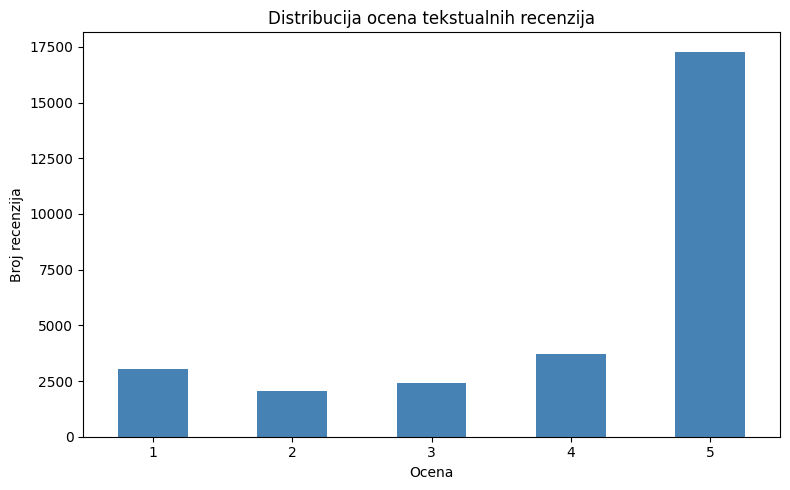

In [126]:
raspodela_popunjenih_ocena = recenzije_za_proveru_teksta['rating'].dropna().value_counts().sort_index()
grafik = raspodela_popunjenih_ocena.plot(kind='bar', figsize=(8, 5), color='steelblue')
grafik.set_title('Distribucija ocena tekstualnih recenzija')
grafik.set_xlabel('Ocena')
grafik.set_ylabel('Broj recenzija')
grafik.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [127]:
udeo_pozitivnih_ocena = recenzije_za_proveru_teksta['rating'].isin([4, 5]).mean() * 100
udeo_negativnih_ocena = recenzije_za_proveru_teksta['rating'].isin([1, 2]).mean() * 100
nedostajuce_ocene = recenzije_za_proveru_teksta['rating'].isna().sum()
neispravne_ocene = (~recenzije_za_proveru_teksta['rating'].isin([1, 2, 3, 4, 5]) & recenzije_za_proveru_teksta['rating'].notna()).sum()
print(f'Ocene 4–5: {udeo_pozitivnih_ocena:.2f}%')
print(f'Ocene 1–2: {udeo_negativnih_ocena:.2f}%')
print(f'Nedostajuće ocene: {nedostajuce_ocene}')
print(f'Nevalidne ocene: {neispravne_ocene}')

Ocene 4–5: 73.65%
Ocene 1–2: 17.84%
Nedostajuće ocene: 0
Nevalidne ocene: 0


### Zaključak

- Ocene 4 i 5 čine 73,65% tekstualnih recenzija.
- Ocene 1 i 2 čine 17,84% tekstualnih recenzija.
- Ocena nije signal tekstualne relevantnosti niti deo naknadnog preuređivanja.
- `page_ocena` i `page_recenzija_count` koriste se samo kada su prethodni ključevi rangiranja potpuno jednaki.

## 6.2 Broj recenzija i pouzdanost prosečne ocene proizvoda

**Proveravamo raspodelu broja tekstualnih recenzija po proizvodu, bez pretvaranja ocene ili popularnosti u signal relevantnosti.**

In [128]:
kanonske_tekstualne_recenzije = (
    recenzije_za_proveru_teksta
    .merge(product_id_map, on="product_link_id", how="left", validate="many_to_one")
    .dropna(subset=["canonical_product_link", "review_id"])
    .sort_values(["canonical_product_link", "review_id"])
    .drop_duplicates(subset=["canonical_product_link", "review_id"], keep="first")
    .copy()
)

pregled_ocena_po_proizvodu = (
    kanonske_tekstualne_recenzije.groupby("canonical_product_link")
    .agg(
        broj_tekstualnih_recenzija=("review_id", "size"),
        prosecna_ocena_u_skupu=("rating", "mean"),
        medijalna_ocena_u_skupu=("rating", "median"),
    )
    .reset_index()
)
pregled_ocena_po_proizvodu["prosecna_ocena_u_skupu"] = pregled_ocena_po_proizvodu["prosecna_ocena_u_skupu"].round(2)

print("Kanonskih tekstualnih recenzija:", len(kanonske_tekstualne_recenzije))
display(pregled_ocena_po_proizvodu["broj_tekstualnih_recenzija"].describe().to_frame())

Kanonskih tekstualnih recenzija: 26052


,broj_tekstualnih_recenzija
count,1267.000000
mean,20.561957
std,7.241375
min,1.000000
25%,19.000000
50%,25.000000
75%,25.000000
max,27.000000


In [129]:
raspodela_broja_recenzija = pd.Series({
    "1 review": pregled_ocena_po_proizvodu["broj_tekstualnih_recenzija"].eq(1).sum(),
    "2–4 reviews": pregled_ocena_po_proizvodu["broj_tekstualnih_recenzija"].between(2, 4).sum(),
    "5–9 reviews": pregled_ocena_po_proizvodu["broj_tekstualnih_recenzija"].between(5, 9).sum(),
    "10–19 reviews": pregled_ocena_po_proizvodu["broj_tekstualnih_recenzija"].between(10, 19).sum(),
    "20+ reviews": pregled_ocena_po_proizvodu["broj_tekstualnih_recenzija"].ge(20).sum(),
}, name="broj_proizvoda").to_frame()

proizvodi_sa_krajnjim_prosekom = pregled_ocena_po_proizvodu[
    pregled_ocena_po_proizvodu["prosecna_ocena_u_skupu"].isin([1.0, 5.0])
]

display(raspodela_broja_recenzija)
print("Proizvodi sa prosekom 1.0 ili 5.0:", len(proizvodi_sa_krajnjim_prosekom))

,broj_proizvoda
1 review,16
2–4 reviews,40
5–9 reviews,97
10–19 reviews,167
20+ reviews,947


Proizvodi sa prosekom 1.0 ili 5.0: 41


### Zaključak

- Broj tekstualnih recenzija nije jednak za sve proizvode.
- Krajnji proseci 1,0 i 5,0 mogu nastati na veoma malom broju recenzija.
- Prosečna ocena ne određuje relevantnost proizvoda.

# 7. Pokrivenost i provera datuma

Merimo raspoloživost teksta po proizvodu i kategoriji, udeo teksta među proizvodima i pouzdanost datuma nastanka recenzije.

## 7.1 Pokrivenost proizvoda recenzijama

In [130]:
pokrivenost_proizvoda_tekstom = kanonski_proizvodi.merge(pregled_ocena_po_proizvodu, on='canonical_product_link', how='left', suffixes=('', '_reviews'), validate='one_to_one')
pokrivenost_proizvoda_tekstom['broj_tekstualnih_recenzija'] = pokrivenost_proizvoda_tekstom['broj_tekstualnih_recenzija'].fillna(0).astype(int)
print('Ukupno kanonskih proizvoda:', len(pokrivenost_proizvoda_tekstom))
print('Bez tekstualnih recenzija:', pokrivenost_proizvoda_tekstom['broj_tekstualnih_recenzija'].eq(0).sum())
print('Sa samo 1–2 tekstualne recenzije:', pokrivenost_proizvoda_tekstom['broj_tekstualnih_recenzija'].between(1, 2).sum())

Ukupno kanonskih proizvoda: 1268
Bez tekstualnih recenzija: 1
Sa samo 1–2 tekstualne recenzije: 33


### Zaključak

- Jedan kanonski proizvod nema tekstualnu recenziju.
- Proizvod bez tekstualne recenzije ostaje u katalogu.
- Za takav proizvod pravi se jedan rezervni odlomak samo od naziva, brenda i kategorije.
- `skup podataka_text_recenzija_count` ostaje mera pokrivenosti, a ne signal relevantnosti.

## 7.2 Pokrivenost kategorija

**Da li recommender možemo primeniti na sve kategorije ili neke kategorije moramo označiti kao slabo pokrivene.**

In [131]:
pokrivenost_kategorija_tekstom = (
    pokrivenost_proizvoda_tekstom
    .groupby("category", dropna=False)
    .agg(
        broj_proizvoda=("canonical_product_link","nunique",),
        ukupan_broj_tekstualnih_recenzija=("broj_tekstualnih_recenzija","sum",),
        prosecan_broj_recenzija_po_proizvodu=("broj_tekstualnih_recenzija","mean",),
        medijalni_broj_recenzija_po_proizvodu=("broj_tekstualnih_recenzija","median",),
        products_without_text=("broj_tekstualnih_recenzija",lambda vrednosti: vrednosti.eq(0).sum(),),
        proizvodi_sa_jednom_ili_dve_recenzije=("broj_tekstualnih_recenzija",lambda vrednosti:vrednosti.between(1, 2).sum()),
    )
    .round(2)
    .sort_values(
        "ukupan_broj_tekstualnih_recenzija",
        ascending=False,
    )
)

display(pokrivenost_kategorija_tekstom)

,broj_proizvoda,ukupan_broj_tekstualnih_recenzija,prosecan_broj_recenzija_po_proizvodu,medijalni_broj_recenzija_po_proizvodu,products_without_text,proizvodi_sa_jednom_ili_dve_recenzije
category,,,,,,
Face Primer,241,5101,21.17,25.0,1,12
Blush,190,3659,19.26,25.0,0,6
Setting Spray & Powder,176,3631,20.63,25.0,0,1
Foundation,154,3373,21.90,25.0,0,0
Concealer,117,2678,22.89,25.0,0,0
Bronzer,110,1981,18.01,25.0,0,7
Highlighter,83,1478,17.81,20.0,0,5
Makeup Remover,45,1037,23.04,25.0,0,0
Contouring,44,861,19.57,25.0,0,1


### Zaključak

- Sve kategorije imaju tekstualne recenzije.
- Samo jedan proizvod u kategoriji `Face Primer` nema tekstualnu recenziju.
- Nijedna kategorija ne izuzima se iz kataloga.
- Analiza po kategoriji dozvoljena je samo kada postoji dovoljan broj jasno pripadajućih tema.

## 7.3 Raspodela količine teksta recenzija

**Da li treba ograničiti
broj recenzija po proizvodu kako proizvodi sa mnogo teksta ne bi
dominirali semantic search modelom.**

In [132]:
pregled_pokrivenosti = pokrivenost_proizvoda_tekstom['broj_tekstualnih_recenzija'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
display(pregled_pokrivenosti.to_frame('vrednost'))

,vrednost
count,1268.000000
mean,20.545741
std,7.261512
min,0.000000
25%,19.000000
50%,25.000000
75%,25.000000
90%,25.000000
95%,25.000000
99%,25.000000


In [133]:
brojevi_recenzija = pokrivenost_proizvoda_tekstom["broj_tekstualnih_recenzija"] .sort_values(ascending=False)
ukupan_broj_recenzija = brojevi_recenzija.sum()
broj_proizvoda = len(brojevi_recenzija)

broj_prvih_deset = min(10, broj_proizvoda)
broj_prvih_deset_posto = max(1,int(broj_proizvoda * 0.10),)

pregled_dominacije = pd.Series(
    {
        "Top 10 products share": (brojevi_recenzija.head(broj_prvih_deset).sum()/ ukupan_broj_recenzija* 100),
        "Top 10% products share": (brojevi_recenzija.head(broj_prvih_deset_posto).sum()/ ukupan_broj_recenzija* 100),
    },
    name="procenat_tekstualnih_recenzija",
).round(2).to_frame()

display(pregled_dominacije)

,procenat_tekstualnih_recenzija
Top 10 products share,0.98
Top 10% products share,12.11


**Da li kombinovani
dokumenti proizvoda moraju da imaju ograničenje ukupne količine teksta.
Isti broj recenzija ne znači nužno i isti broj reči.**

In [134]:
obim_teksta_po_proizvodu = (
    kanonske_tekstualne_recenzije
    .groupby("canonical_product_link")
    .agg(
        broj_tekstualnih_recenzija=("review_id", "size"),
        ukupan_broj_reci_recenzija=("broj_reci_teksta_recenzije","sum",),
        medijalni_broj_reci_recenzija=("broj_reci_teksta_recenzije","median",),
        najveci_broj_reci_recenzija=("broj_reci_teksta_recenzije","max",),
    )
    .reset_index()
)

pregled_obima_teksta = (
    obim_teksta_po_proizvodu["ukupan_broj_reci_recenzija"]
    .describe(percentiles=[0.25,0.50,0.75,0.90,0.95,0.99,])
    .round(2)
)

display(pregled_obima_teksta.to_frame("ukupan_broj_reci_recenzija"))

,ukupan_broj_reci_recenzija
count,1267.00
mean,983.38
std,466.76
min,17.00
25%,702.00
50%,1000.00
75%,1264.00
90%,1514.80
95%,1646.10
99%,1997.02


In [135]:
brojevi_reci = obim_teksta_po_proizvodu["ukupan_broj_reci_recenzija"].sort_values(ascending=False)


ukupan_broj_reci = brojevi_reci.sum()
broj_prvih_deset_posto = max(1,int(len(brojevi_reci) * 0.10))

pregled_udela_reci = pd.Series(
    {
        "Top 10 products share": (brojevi_reci.head(10).sum()/ ukupan_broj_reci* 100),
        "Top 10% products share": (brojevi_reci.head(broj_prvih_deset_posto).sum()/ ukupan_broj_reci* 100),
        "Largest document / median document": (brojevi_reci.max()/ brojevi_reci.median()),
    },
    name="vrednost",
).round(2).to_frame()

display(pregled_udela_reci)

,vrednost
Top 10 products share,2.33
Top 10% products share,17.95
Largest document / median document,4.47


### Zaključak

- Nekoliko proizvoda ne dominira ukupnim skupom recenzija.
- Deset proizvoda sadrži 2,33% svih reči, a prvih 10% proizvoda sadrži 17,95%.
- Recenzije se ne skraćuju niti uzorkuju radi izjednačavanja proizvoda.
- Svaka validna recenzija ostaje zaseban odlomak.

## 7.4 Vremenski raspon 

Proveravamo uspešnost pretvaranja `created_date` u UTC vreme i opisujemo vremenski raspon skupa podataka. Datum nije osnova podele za evaluaciju niti signal relevantnosti.

In [136]:
kanonske_tekstualne_recenzije["created_datetime"] = pd.to_datetime(kanonske_tekstualne_recenzije["created_date"],errors="coerce",utc=True,)

pregled_kvaliteta_datuma = pd.Series(
    {
        "total reviews": len(kanonske_tekstualne_recenzije),
        "valid dates": (kanonske_tekstualne_recenzije["created_datetime"].notna().sum()),
        "invalid or missing dates": (kanonske_tekstualne_recenzije["created_datetime"].isna().sum()),
    },
    name="broj_recenzija",
).to_frame()
display(pregled_kvaliteta_datuma)

print("Najranija recenzija:",kanonske_tekstualne_recenzije["created_datetime"].min(),)
print("Najnovija recenzija:",kanonske_tekstualne_recenzije["created_datetime"].max(),)

,broj_recenzija
total reviews,26052
valid dates,26052
invalid or missing dates,0


Najranija recenzija: 2014-03-27 02:42:00+00:00
Najnovija recenzija: 2024-07-28 06:44:16+00:00


,broj_recenzija
godina_recenzije,
2014,2
2015,4
2016,16
2017,26
2018,63
2019,140
2020,349
2021,803
2022,2745


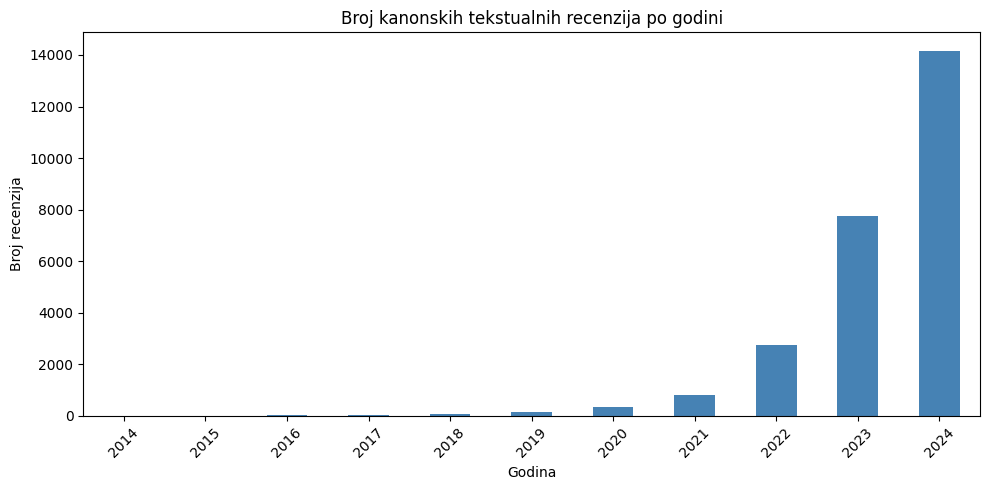

In [137]:
recenzije_po_godini = kanonske_tekstualne_recenzije.dropna(subset=['created_datetime']).assign(godina_recenzije=lambda tabela: tabela['created_datetime'].dt.year)['godina_recenzije'].value_counts().sort_index().rename('broj_recenzija').to_frame()
display(recenzije_po_godini)
grafik = recenzije_po_godini.plot(kind='bar', figsize=(10, 5), legend=False, color='steelblue')
grafik.set_title('Broj kanonskih tekstualnih recenzija po godini')
grafik.set_xlabel('Godina')
grafik.set_ylabel('Broj recenzija')
grafik.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Zaključak

- Svi datumi nastanka kanonskih tekstualnih recenzija uspešno su pretvoreni u UTC vreme.
- Oko 84% recenzija potiče iz 2023. i nepotpune 2024. godine.
- Datum se čuva radi provere porekla podataka.
- Razvojni i test skup dele teme upita, a ne recenzije po vremenu.

# 8. Završni pregled



| Nalaz | Potvrda u podacima | Usvojena odluka |
|---|---|---|
| Izvorni red proizvoda nije isto što i kanonski proizvod | 1.373 reda proizvoda daju 1.268 kanonskih adresa | Rangira se kanonski proizvod, dok se SKU varijante čuvaju odvojeno |
| `item_id` nije potpun | SKU iz adrese i identifikator iz opisa slažu se u svih 1.373 reda | Formira se `item_id_clean` |
| Deo recenzija nema poznat proizvod | 8.298 redova ne može da se poveže sa tabelom proizvoda | Redovi se čuvaju u `unmatched_reviews` i ne indeksiraju se |
| Izvorni red recenzije nije nužno zasebna recenzija | Tekstualni i medijski redovi dele isti logički identitet | Formira se `reviews_canonical` |
| Tekstualne recenzije pokrivaju skoro ceo katalog | Samo jedan kanonski proizvod nema tekstualnu recenziju | Za taj proizvod koristi se rezervni odlomak bez tvrdnji o učinku |
| Brojevi recenzija imaju različito statističko poreklo | Broj u skupu podataka razlikuje se od broja prikazanog na platformi | Grupe statističkog porekla čuvaju se odvojeno |
| Ocene su izrazito pomerene ka pozitivnim vrednostima | Ocene 4 i 5 čine 73,65% tekstualnih recenzija | Ocena nije signal relevantnosti |
| Strukturisana vrednost brenda nije potpuna | Pronađene su nedostajuće vrednosti i natpisi korisničkog interfejsa | Koristi se `brand_final` uz zabeležen izvor odluke |
| Postoje dva semantička sukoba kategorije | Tehničko ujednačavanje nije otkrilo pravopisne varijante | Koristi se `category_primary`, uz čuvanje `category_all` i izvora odluke |
| Cena je potpuna i brojčano ispravna | Nema nedostajućih, nultih ili negativnih vrednosti | Cena se koristi samo kao strogi brojčani uslov filtriranja |
| Opis sadrži delove stranice koji nisu opis proizvoda | Potvrđeni su ponovljeni navigacioni i komercijalni delovi | Čuvaju se `description_raw` i `description_clean` |
| Platformski sažeci potiču iz korisničkih odgovora | Polja `pros`, `cons`, `best_uses` i `faceoff_*` nisu nezavisan opis | Ne koriste se za pretragu, spajanje rang-lista ili dokaz podudaranja |
| Tekst sadrži HTML entitete i moguće greške kodiranja | Pronađena su 962 HTML entiteta i označeni sumnjivi zapisi | Tekst se dekodira i normalizuje, uz čuvanje izvornog sadržaja |
| Datum nije osnova podele za evaluaciju | `created_date` je moguće pouzdano pretvoriti u UTC vreme | Razvojni i test skup dele teme upita, a ne recenzije po vremenu |


### Zaključani oblici tekstualnih dokumenata

- Dokument opisa sadrži polja `Name`, `Brand`, `Category` i `Description`, po jedan za svaki kanonski proizvod.
- Odlomak recenzije sadrži polja `Name`, `Brand`, `Category` i `Review`, po jedan za svaku validnu kanonsku tekstualnu recenziju.
- Proizvod bez indeksiranog teksta recenzije dobija jedan rezervni odlomak sa nazivom, brendom i kategorijom.
- Cena, ocene, brojevi recenzija, platformski sažeci i statistike skupa podataka ne ulaze u tekst za pretragu.
- Kategorija, brend i najveća cena ostaju strogi strukturisani uslovi filtriranja.
